# DEFINITIONS

In [41]:
def open_file(path,name):
    ''' Open the parquet file'''
    df = pd.read_parquet(os.path.join(path,name))
    return df

def filter_by_period(df,period_division,n_period):
    '''df: dataframe parquet
    period_division : list of datetimes
    Returns the df with people that have recorded their position
    in the interval of time period_divisio[n_period]-period_divisio[n_period+1]   '''
    df=df.loc[df['begin']>period_division[n_period]]
    df=df.loc[df['begin']<period_division[n_period+1]]
    return df

def filter_people_by_np(df,np_):
    '''Outputs the list of people that have more then np_ points
    in their trajectory'''
    infos_dict = df.groupby('userId')
    size_series = infos_dict.size().sort_values()
    list_uid = size_series[size_series>np_].index                
    print('number of people which have more than {} points:'.format(np_),len(list_uid))
    return list_uid    

def spatial_filtering_per_country(std1,buonding_box):
    '''US:[(18.91619,-171.791110603 ), (71.3577635769,-171.791110603), (71.3577635769, -66.96466),(18.91619,-66.96466 ) ]'''
    l=list(zip(std1['lat'],std1['lng']))
    points = [Point(ll) for ll in l]
    polygon=Polygon(bounding_box)
    mask=[point.within(polygon) for point in points]
    std1=std1.loc[mask]
    return std1

def get_time_diff(df):
    ''' give t_threshold an int value meaning hours
    Adds a column time_diff that contains the difference in times between two successive
    rows of dataframe 
    '''
    list_time_diff =[0]
    df=df.sort_values(by = 'begin')
    list_time_diff.extend(((np.roll(df.end.to_numpy(dtype = 'datetime64[s]'),-1)-df.end.to_numpy(dtype = 'datetime64[s]'))/3600).astype(int).tolist())
    list_time_diff.pop()
    df['time_diff'] = list_time_diff
    list_stop_time = (df['end'] -df['begin']).to_list()
    return list_time_diff,list_stop_time

    
def filter_by_unknown_position(df,q,filter_q_true,list_uid_bigger_np_):
    '''Returns list of people whose activity are apart for more then 1
    hour for q % of time'''
    list_q = []
    list_uid = []
    for df_person,group in df.groupby('userId'):
        if filter_q_true:
            df_person=df_person.sort_values(by = 'end')
            list_time_diff =[0]
            list_time_diff.extend(((np.roll(df.begin.to_numpy(dtype = 'datetime64[s]'),-1)-df.end.to_numpy(dtype = 'datetime64[s]'))/3600).astype(int).tolist())
            q = len(list_time_diff[list_time_diff<1])/len(list_time_diff)
            if group in list_uid_bigger_np_:                
                list_q.append(q)
                list_uid.append(group)
    return list_q,list_uid




def create_empty_dictionary(period_names,list_points):
    dict_={}
    for period in range(len(period_names)):
        dict_[period_names[period]] = {}
        for np_ in list_points:
            dict_[period_names[period]][np_] = []
    return dict_



def time_filtering_traj_per_person(df,t_threshold,t_threshold_true):
    ''' give t_threshold an int value meaning hours'''
    if t_threshold_true:
        list_time_diff =[0]
        df=df.sort_values(by = 'end')
        list_time_diff.extend(((np.roll(df.end.to_numpy(dtype = 'datetime64[s]'),-1)-df.end.to_numpy(dtype = 'datetime64[s]'))/3600).astype(int).tolist())
        list_time_diff.pop()
        df['time_diff'] = list_time_diff
        df = df.loc[df['time_diff']<t_threshold]
        t_threshold_name =str(t_threshold)
        print('length of the time thresholded dataframe at {0}: \t {1}'.format(t_threshold,len(df)))
    else:
        t_threshold_name = ''
    return df

def calculate_vectorial_quantities(period_names,list_,path,period_division,quantity_to_calculate,t_threshold,t_threshold_true,bounding_box):
    for period in range(len(period_names)):
        number_people_per_period = [0,0,0]
        number_points_per_period = [0,0,0]
    #FILLING DICTIONARIES WITH RG and (X/SIGMAX,Y/SIGMAY)            
        for name in list_:
            df = open_file(path,name)
            filter_by_period(df,period_division,period)
            subs=name.split('.')[0]
            
            t_threshold_name = ''
            if t_threshold_true: df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true); t_threshold_name =str(t_threshold)
            
            for np_ in list_points:
                if quantity_to_calculate == 'gonzalez':
                    list_xsigmax,list_ysigmay,list_sx,list_sy =[],[],[],[]
                    if no_scaled:
                        dataframe_month_point=pd.DataFrame(columns=['x','y'])
                    else:
                        dataframe_month_point=pd.DataFrame(columns=['x_sigmax','y_sigmay'])
                    dataframe_sigma=pd.DataFrame(columns=['sigma_x','sigma_y'])
                else:
                    list_q, list_uid, list_entropy = [],[],[] 
                    dataframe_month_point=pd.DataFrame(columns=['real_entropy'])
                # select people with more then np_ points in the trajectory
                infos_dict=df.groupby('userId')
                size_series=infos_dict.size().sort_values()
                list_uid=size_series[size_series>np_].index
                list_q0,list_uid0 = filter_by_unknown_position(df,q,filter_q_true,list_uid_bigger_np_)
                list_q.extend(list_q0)
                list_uid = list_uid0
                for person in list_uid:
                    number_people_per_period[period] = number_people_per_period[period] + 1
                    if quantity_to_calculate == 'gonzalez':
                        if no_scaled:
                            dataframe_person=pd.DataFrame(columns=['x','y'])
                        else:
                            dataframe_person=pd.DataFrame(columns=['x_sigmax','y_sigmay'])
                    else:
                        dataframe_person=pd.DataFrame(columns=['real_entropy'])
# constructing radius_gyration
                    df_person_month_np = infos_dict.get_group(person)
                    std1 = skmob.TrajDataFrame(df_person_month_np, latitude='clusterLatitude', longitude='clusterLongitude', datetime='begin', user_id='userId')
                    std1 = spatial_filtering_per_country(std1,bounding_box)
                    number_points_per_period[period] = number_points_per_period[period] + len(std1)
                    if quantity_to_calculate == 'gonzalez':
                        l_sigmal, sigmas = Gonzalez(df_person_month_np,no_scaled)
                        list_xsigmax.extend(np.array(l_sigmal).T[0].tolist())
                        list_ysigmay.extend(np.array(l_sigmal).T[1].tolist())
                        list_sx.append(np.array(sigmas)[0])
                        list_sy.append(np.array(sigmas)[1])
                    else:
                        real_entropy = skmob.measures.individual.real_entropy(std1,show_progress=False)
                        list_entropy.extend(real_entropy['real_entropy'])
                    del std1
                if quantity_to_calculate == 'gonzalez':
                    if no_scaled:
                        dataframe_month_point['x'] = list_xsigmax
                        dataframe_month_point['y'] = list_ysigmay
                    else:
                        dataframe_month_point['x_sigmax'] = list_xsigmax
                        dataframe_month_point['y_sigmay'] = list_ysigmay                
                    dataframe_sigma['sigma_x'] = list_sx
                    dataframe_sigma['sigma_y'] = list_sy
                else:
                    dataframe_month_point['real_entropy'] = list_entropy
                if quantity_to_calculate == 'gonzalez':
                    if no_scaled:
                        dataframe_month_point.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}_no_scaled.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")
                        print('I have saved:','milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}_no_scaled.csv.gz'.format(subs,period_names[period],np_))
                    else:
                        dataframe_month_point.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")
                        print('I have saved:','milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_))
                    dataframe_sigma.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_sigma_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")            
                else:
                    if not os.path.exists('milestones_analysis/real_entropy_csv_division_time_included'):
                        os.mkdir('milestones_analysis/real_entropy_csv_division_time_included')
                        dir_ = 'milestones_analysis/real_entropy_csv_division_time_included'
                        name_file = 'real_entropy_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_)
                        dataframe_month_point.to_csv(os.path.join(dir_,name_file),';',compression="gzip")
                        print('I have saved:',os.path.join(dir_,name_file))
        print('number of people during the period {0} '.format(period_names[period]),number_people_per_period[period])
        print('number of points during the period {0} '.format(period_names[period]),number_points_per_period[period])
    return True

def powerlaw_fit_and_plot(data,xmin_,xmax_):
    fit = powerlaw.Fit(data, xmin=xmax_, xmax =xmax_)
    print('KS distance \t', fit.power_law.D)        
    alpha = fit.power_law.alpha
    sigma =  fit.power_law.sigma
    print('sigma \t {}'.format(sigma),'\t alpha \t {}'.format(alpha))
    R,p=fit.distribution_compare('power_law', 'exponential')
    print('log likelihood between power law and expo {}'.format(R),'significance value {}'.format(p))
    if R<0:
        print('more probable that the fit is an exponential')
    else:
        print('more probable that the fit is a power law')
    #powerlaw.plot_pdf(data, color='b')#linear_bin = True
    fit.power_law.plot_pdf(color='b', linestyle='--')
#    powerlaw.plot_cdf(data, color=’b’)
#    powerlaw.plot_ccdf(data, color=’b’)
    
        


def calculate_save_skmob_scalar_per_period_in_dictionary(period_names,period_division,list_points,list_,path,dict_,quantity_to_calculate,t_threshold,t_threshold_true):
    '''period_names: list of time intervals.
    list_: list of file names ,
    path: directory where I have the file to construct the df,
    dict_: dictionary such that dict_[period_names[i]][np_],
    quantity_to_calculate: str(uncorrelated_entropy) or whatever is skmob that produces a scalar for each trajectory
    t_threshold: int hours above which the we consider two point in a traj
    It is thought to be used for: ['radius_of_gyration','random_entropy','uncorrelated_entropy','distance_straight_line']
    '''
#CONTROL PARAMETERS    
    total_number_of_people_all_periods = 0
    number_of_people_per_period = []
    for period in range(len(period_names)):
        total_number_of_points_in_all_trajectories = 0
        number_of_people = 0
        for name in list_:
            df = open_file(path,name)
            df = filter_by_period(df,period_division,n_period)
            subs=name.split('.')[0]
            print('number of people in {0}: {1} coming from file {2}'.format(period_names[period],len(df),subs))
            df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true)
            number_of_people_per_period.append(number_of_people) 
            for np_ in list_points:
                list_uid = filter_people_by_np(df,np_)                
                if np_==20:
                    number_of_people = number_of_people + len(list_uid)
    #            print('number of people for month {0} and number of people {1}: '.format(g,np_),'\t',len(list_uid))
                n_people = 0
                for person in list_uid:
                    # constructing quantity_to_calculate
                    df_person_month_np = infos_dict.get_group(person)
                    if np_==20:
                        total_number_of_points_in_all_trajectories = total_number_of_points_in_all_trajectories + len(df_person_month_np)
                    std1=skmob.TrajDataFrame(df_person_month_np, latitude='clusterLatitude', longitude='clusterLongitude', datetime='begin', user_id='userId')
                    std1 = spatial_filtering_per_country(std1,bounding_box)
                    if quantity_to_calculate == 'random_entropy':
                        quantity=skmob.measures.individual.random_entropy(std1,show_progress = False)
                        dict_[period_names[period]][np_].append(quantity.iloc[0][quantity_to_calculate])
                    elif quantity_to_calculate == 'uncorrelated_entropy':
                        quantity=skmob.measures.individual.uncorrelated_entropy(std1,show_progress = False)
                        dict_[period_names[period]][np_].append(quantity.iloc[0][quantity_to_calculate])
                    elif quantity_to_calculate=='radius_of_gyration':
                        quantity=skmob.measures.individual.radius_of_gyration(std1,show_progress = False)
                        dict_[period_names[period]][np_].append(quantity.iloc[0][quantity_to_calculate])
                    elif quantity_to_calculate =='distance_straight_line':
                        quantity=skmob.measures.individual.distance_straight_line(std1,show_progress = False)
                        dict_[period_names[period]][np_].append(quantity.iloc[0][quantity_to_calculate])
                    del std1                
        print('total number of points in trajectories {0} of the period {1}'.format(period_names[period],total_number_of_points_in_all_trajectories))
        print('total number of people in trajectories {0} of the period {1}'.format(period_names[period],number_of_people))
        
    if t_threshold_true:  
        print('now I save',"milestones_analysis/{0}_dictionary/dict_{1}_bimonth__threshold_{2}_hour.json".format(quantity_to_calculate,quantity_to_calculate,t_threshold_name))
        if not os.path.exists("milestones_analysis/{0}_dictionary".format(quantity_to_calculate)):
            os.mkdir("milestones_analysis/{0}_dictionary".format(quantity_to_calculate))
        with open("milestones_analysis/{0}_dictionary/dict_{1}_bimonth__threshold_{2}_hour.json".format(quantity_to_calculate,quantity_to_calculate,t_threshold_name),"w") as f:
            json.dump(dict_,f)
    else:
        print('now I save:',"milestones_analysis/{0}_dictionary/dict_{1}_bimonth.json".format(quantity_to_calculate,quantity_to_calculate))
        if not os.path.exists("milestones_analysis/{0}_dictionary".format(quantity_to_calculate)):
            os.mkdir("milestones_analysis/{0}_dictionary".format(quantity_to_calculate))
        with open("milestones_analysis/{0}_dictionary/dict_{1}_bimonth.json".format(quantity_to_calculate,quantity_to_calculate),"w") as f:
            json.dump(dict_,f)
    print('shape of number_of_people_per_period',np.shape(number_of_people_per_period),'== to expected 48?',np.shape(number_of_people_per_period)==48)
    
    return True



def plot_saved_skmob_scalar_per_period(np_,scaling_rg,period_names,quantity_to_calculate,t_threshold,no_log,t_threshold_true,list_xmin,list_xmax):
    if quantity_to_calculate != 'distance_straight_line':
        for period in range(len(period_names)):
            with open("milestones_analysis/{0}_dictionary/dict_{1}_bimonth__threshold_{2}_hour.json".format(quantity_to_calculate,quantity_to_calculate,t_threshold_name),"r") as f:
                dict_=json.load(f)
            if scaling_rg and (quantity_to_calculate=='radius_of_gyration'):
                    quantity=[k for k in np.array(dict_[period_names[period]][np_]) if k>0.1]
                    quantity = np.array(quantity)/np.array(dict_[period_names[period]][np_]).mean()            
                    print('number of people for radius of gyration',len(quantity),'average period {0} is {1} '.format(period_names[period],np.array(dict_[period_names[period]][np_]).mean()))
            elif quantity_to_calculate=='radius_of_gyration':
                quantity=[k for k in np.array(dict_[period_names[period]][np_]) if k>0.1]
            else:
                quantity=[k for k in list(dict_[period_names[period]][np_]) if k>0.1]            
            if 'entropy' in quantity_to_calculate and no_log:
                q,a=histFloat(quantity,200)
                plt.scatter(a,q)
            else:
                q,a,dq=logHist(quantity,200)
#                powerlaw_fit_and_plot(quantity,set_xmin = True)
                plt.loglog(a,q)
            if scaling_rg and quantity_to_calculate=='radius_of_gyration':
                plt.xlabel('radius of gyration/ <radius of gyration>')#plt.xlabel('{0}/<{1}>'.format(quantity_to_calculate,quantity_to_calculate))
            else:
                plt.xlabel('radius of gyration (km)')#plt.xlabel('{}'.format(quantity_to_calculate))
            plt.ylabel('PDF')
            #plt.title('number points > {0}'.format(np_))
            plt.legend(period_names)
        if scaling_rg:
            if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate))):
                os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate)))
            plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate),'loglog_no{}_scaled_rg'.format(quantity_to_calculate)))
        else:
            if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate))):
                os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate)))
            plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate),'loglog_no{0}_{1}'.format(np_,quantity_to_calculate)))
        plt.show()
    else:
        c=0
        for period in range(len(period_names)):
            with open("milestones_analysis/{0}_dictionary/dict_{1}_bimonth_{2}_no_people.json".format(quantity_to_calculate,quantity_to_calculate,period_names[period]),"r") as f:
                dict_ = json.load(f)

            quantity=[k for k in list(dict_[period_names[period]][np_]) if k>100]
            powerlaw_fit_and_plot(quantity,list_xmin[c],list_xmax[c])
            print('month',period_names[period])
            q,a,dq=logHist(quantity,200)
#            powerlaw_fit_and_plot(quantity,set_xmin = True)
            plt.loglog(a,q)
            plt.xlabel('{}'.format('L (meters)'))
            plt.ylabel('PDF')
            plt.title('real distance')#plt.title('number points > {0}, < threshold {1} (hours)'.format(np_,t_threshold))
            c = c + 1
        plt.legend(period_names)
        if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate))):
            os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate)))
        plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate),'loglog_no{0}_{1}'.format(quantity_to_calculate,t_threshold)))
        plt.show()    
        for period in range(len(period_names)):
            with open("milestones_analysis/{0}_dictionary/dict_{1}_bimonth_{2}_no_people.json".format(quantity_to_calculate,quantity_to_calculate,period_names[period]),"r") as f:
                dict_ = json.load(f)

            quantity=[k for k in list(dict_[period_names[period]][np_]) if k>100]
            print('month',period_names[period],'average distance ',np.array(quantity).mean(),'median distance',np.median(np.array(quantity)))
            q,a,dq=logHist(quantity,200)
#            powerlaw_fit_and_plot(quantity,set_xmin = True)
            plt.loglog(a,q*np.array(quantity).mean())
            plt.xlabel('{}'.format('L (meters)'))
            plt.ylabel('PDF*<L>')
            plt.title('real distance')#plt.title('number points > {0}, < threshold {1} (hours)'.format(np_,t_threshold))
        plt.legend(period_names)
    if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate))):
        os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate)))
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format(quantity_to_calculate),'loglog_no{0}_{1}'.format(quantity_to_calculate,t_threshold)))
    plt.show()
        
    return True            
    return True    

### S(t) functions
def n_new_visits(data):
    visits_error = False
    list_visited = []
    list_count_new = []
    count_new = 0
    for x in data:
        if x not in list_visited:
            count_new = count_new + 1
            list_count_new.append(count_new)
            list_visited.append(x)
        else:
            list_count_new.append(count_new)
#            list_visited.append(x)
    for t in range(len(list_count_new)-1):
        if list_count_new[t]>list_count_new[t+1]:
            print('something with counting new visits is wrong')
            visits_error = True
            break
    
    return list_count_new,visits_error
def get_time_passing(df):
    '''Adds a column time_diff that contains the difference in times between two successive
    rows of dataframe 
    '''
    time_error = False
    list_time_diff =[0]
    df=df.sort_values(by = 'begin')
    # list of hours passed from the beginning, length of the list = number of stop points
    list_time_diff.extend(((df.begin.to_numpy(dtype = 'datetime64[s]')-df.begin.to_numpy(dtype = 'datetime64[s]')[0])/3600).astype(int).tolist())
    list_time_diff.pop()
    for t in range(len(list_time_diff)-1):
        if list_time_diff[t]>list_time_diff[t+1]:
            print('something with time ordering is wrong')
            print(list_time_diff)
            time_error = True
            break
            
    return list_time_diff,time_error

def S_t(list_files_path,period_division,period_names,time_interval_s,dict_s):
    '''Input:
    list_files_path: list of files to be read. [/home/aamad/subset_1.snappy.parquet,...,...]
    period_division: list of datetime [datetime(1,1,2022),...,] -> partition in time
    period_names: list_of names of periods ['jan-march',...,] -> names partition
    time_interval_s: np.linspace(0,h_interval,h_spacing)
    dict_s = {period_names[0]('jan-march'):{0: , 1: , ... ,h_interval: },.., period_names[n]}
    ---------------------------------
    Description:
    A) for each period in period_division: -> prd
        **********
        number_iteration before changing = |file| * |people|
        **********
        -- prd = fixed --
        -- file = changing --
        --  person = changing changing --
        -- stop-time = changing changing chenging --
        B) for each file in the directory:->file
            **********
            number_iteration before changing =  |people|
            **********
            -- prd = fixed --
            -- file = fixed --
            -- person = changing --
            -- stop-time = changing changing --
            1) Open file
            2) Filter trajectories: 
                2a) Stop points closer then one hour
                2b) Number of points bigger then np_ 
                2c) Period
            
            C) for person in list_people:
                1) create a list of successive stop-times intervals -> i.e. t_jan = [0,5,100,..,h_max]
                2) create a list of successive unique-visits 1<->1 with above -> i.e. s_jan = [0,0,1,2,2,...,s_max]
                
                D) for e in list of stop-times:
                1) initialize h as the stop_time t_jan[e]
                2) check not at the end
                3) go until t_jan[e+1] adding dict_s[prd][h] wiht the count if e is not the last element
                4) once u achieve the last element of the list, fill the missing data with the last element. (elif e==len(t_jan)-1)
                
                
                    
    ---------------------------------
    Output:
    dict_s:
    dict_s.keys() in period_names ['jan-march',...]
    dict_s.values() = dict_s_values, dict_s_values.keys() in time_interval_s [0,...,h_interval]
    dict_s_values.values() = [S_0t,...,S_npeoplet] -> count of different positions visited by all the people at their intrinsic time-frame.
    
    '''
    for prd in range(len(period_division)):
        for file in list_files_path:
            # START FIRST COMMON FILTER
            df = pd.read_parquet(file)
            df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true)    
            # END FIRST COMMON FILTER
        #### JAN 
            df_jan=df.loc[df['begin']>period_division[prd]].copy()
            df_jan=df_jan.loc[df_jan['begin']<period_division[prd + 1]]
            list_uid = filter_people_by_np(df_jan,np_)
            infos_dict = df_jan.groupby('userId')
            for person in list_uid:
                dfg = infos_dict.get_group(person)
                t_jan,time_error = get_time_passing(dfg)
                s_jan,visits_error = n_new_visits(dfg['geohash7'])
                if time_error == True or visits_error == True:
                    print('something wrong has happened with',person,'break and pass to next person')
                    break
                if len(s_jan)!= len(t_jan):
                    print('s and t dont have same n of elements for',person,'in january')
                    break
                t0 = time.time()
                # for each stop location of the user at steak 
                for e in range(len(t_jan)):
                    h = t_jan[e]
                    # dividing the time in periods [t_jan[e],t_jan[e]+1,...,t_jan[e+1]]
                    if e<len(t_jan)-1 and t_jan[e+1]-t_jan[e]>0 : # if I have not arrived at the end (as I will call the successive element of the iterator at e), and if the time is increasin
                        for i in range(t_jan[e+1]-t_jan[e]): # as many times as the hours between two successive events
                            if e<len(t_jan)-1: # redundantly ensuring that e is not the last element and I can take the iterator e+1
                                if h==t_jan[e] or (t_jan[e]<h and h<t_jan[e+1]): # take just those cases for which the hour is in 
                                    if h<max(time_interval_s):
                                        dict_s[period_names[prd]][h].append(s_jan[e])
                                        h = h +1
                                elif h<t_jan[e]:
                                    pass
                                else:
                                    break
                            elif e==len(t_jan)-1:
                                while h<max(time_interval_s):
                                    dict_s[period_names[prd]][h].append(s_jan[e])
                                    h = h+1
                t1 = time.time()
        return dict_s


# ENTROPIC COMPARISON

# EXECUTION

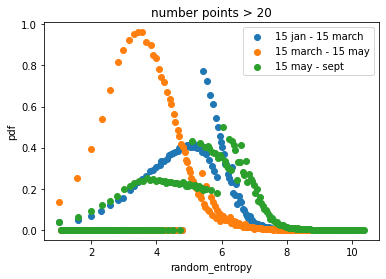

<Figure size 432x288 with 0 Axes>

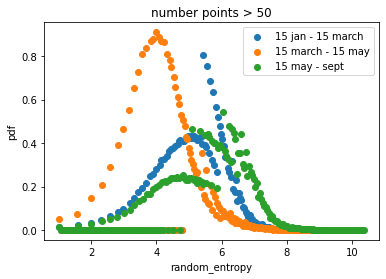

<Figure size 432x288 with 0 Axes>

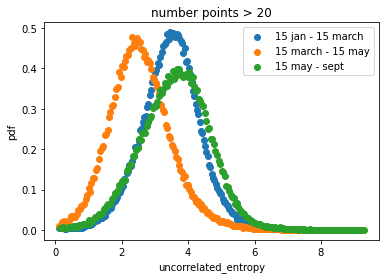

<Figure size 432x288 with 0 Axes>

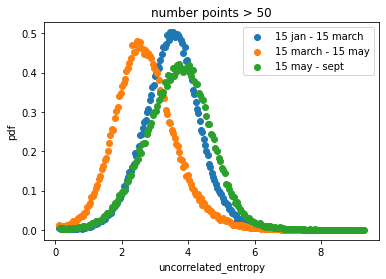

<Figure size 432x288 with 0 Axes>

distance_straight_line 1 15 may - sept 20
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


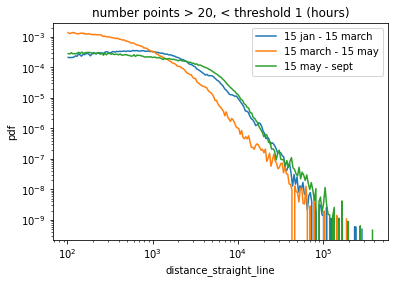

distance_straight_line 1 15 may - sept 50
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


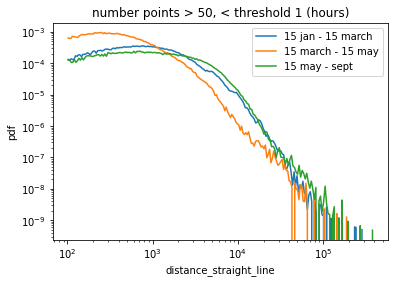

distance_straight_line 2 15 may - sept 20
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


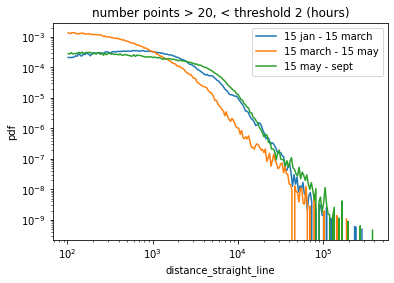

distance_straight_line 2 15 may - sept 50
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


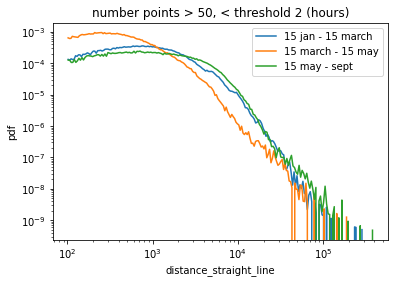

distance_straight_line 5 15 may - sept 20
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


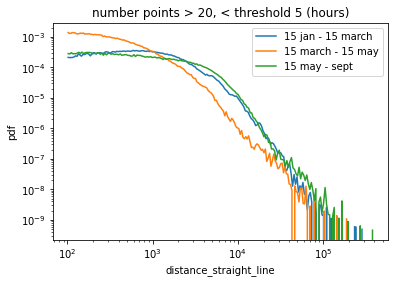

distance_straight_line 5 15 may - sept 50
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


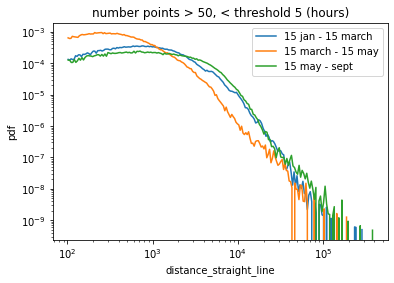

distance_straight_line 10 15 may - sept 20
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


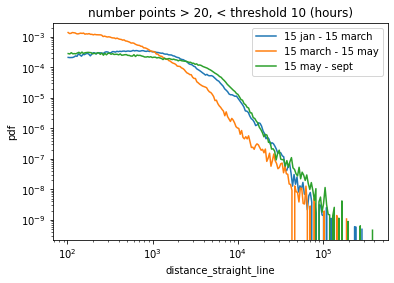

distance_straight_line 10 15 may - sept 50
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


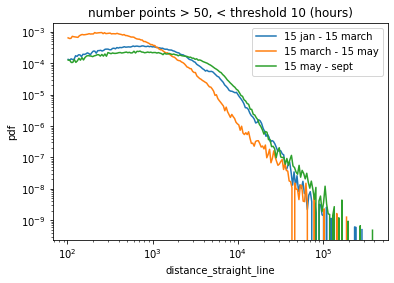

distance_straight_line 15 15 may - sept 20
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


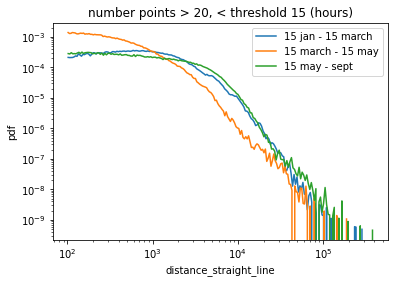

distance_straight_line 15 15 may - sept 50
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


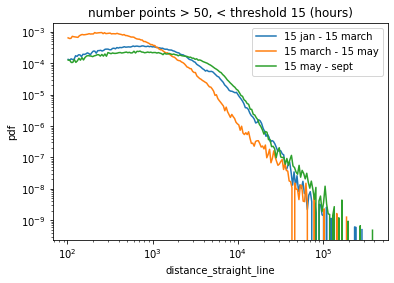

distance_straight_line 24 15 may - sept 20
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


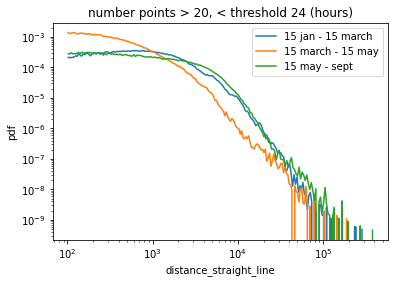

distance_straight_line 24 15 may - sept 50
month 15 jan - 15 march
month 15 march - 15 may
month 15 may - sept


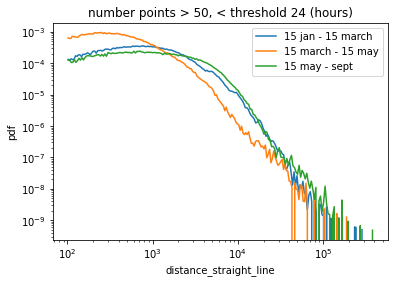

In [47]:
import skmob
from skmob.measures.individual import waiting_times
from datetime import datetime
import math    
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.insert(1,'/data/rgallotti/libraries/PythonScripts/')
from rg_histograms import cumulative,histInt,histFloat,logHist
from rg_fits import power_fit
import geohash
import os
from shapely import *
from geohash_grid import * 
import geopandas as gpd
import warnings
import json
import time
warnings.filterwarnings('ignore')

##### GLOBAL VARIABLES ######
list_quantity_to_calculate = ['radius_gyration','random_entropy','uncorrelated_entropy','distance_straight_line']
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)

### CALCULATE ARGUMENTS ###
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
period_division = [half_jan,half_march,half_may,september]
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
list_=['subset_1.snappy.parquet','subset_2.snappy.parquet','subset_3.snappy.parquet','subset_4.snappy.parquet','subset_5.snappy.parquet','subset_6.snappy.parquet','subset_7.snappy.parquet','subset_8.snappy.parquet','subset_9.snappy.parquet','subset_a.snappy.parquet','subset_b.snappy.parquet','subset_c.snappy.parquet','subset_d.snappy.parquet','subset_e.snappy.parquet','subset_f.snappy.parquet']

path_df = '/data/shared/cuebiq/MOBS/20220330_stops_hq_users_MA'

#### LOADING VARIABLES AND PATHS ####
save_dir = '/home/aamaduzzi'
legend = ['sigma_x','sigma_y']
no_scaled = False
quantity_to_calculate = 'radius_gyration'
#df_index=pd.read_csv('milestones_analysis/{0}_division_time_included/month_rg_userId_indeces.csv'.format(quantity_to_calculate),';')
#list_month=np.unique(df_index['month'])

with open("milestones_analysis/radius_gyration/dict_radius_gyration_bimonth_no_people.json","r") as f:
    dict_df = json.load(f)
list_np_ = [20,50]#,100,200,400]
list_np_string = ['20','50']#,'100','200','400']
list_t_threshold = [1,2,5,10,15,24]#[1,2,5,10,15,24]
scaling_rg =False
already_calculated = True
no_log=True


if __name__=='__main__':
    if already_calculated:    
        for quantity_to_calculate in list_quantity_to_calculate[1:]:
            if quantity_to_calculate == 'distance_straight_line':
                for t_threshold in list_t_threshold:
                    for np_ in list_np_string:
                        try:
                            print(quantity_to_calculate,t_threshold,period_names[period],np_)
                            plot_saved_skmob_scalar_per_period(np_,scaling_rg,period_names,quantity_to_calculate,t_threshold,no_log)
                        except:
                            pass
            else:
                t_threshold = 0
                for np_ in list_np_string:
                    plot_saved_skmob_scalar_per_period(np_,scaling_rg,period_names,quantity_to_calculate,t_threshold,no_log)

    else:
        for quantity_to_calculate in list_quantity_to_calculate[1:]:
            print(quantity_to_calculate)
            if quantity_to_calculate == 'distance_straight_line':   
                for t_threshold in list_t_threshold:
                    print('t_threshold',t_threshold)
                    dict_ = create_empty_dictionary(period_names,list_np_)
                    already_calculated = calculate_save_skmob_scalar_per_period_in_dictionary(period_names,period_division,list_np_,list_,path_df,dict_,quantity_to_calculate,t_threshold)
                    for np_ in list_np_:
                        plot_skmob_scalar_per_period(np_,dict_,scaling_rg,period_names,quantity_to_calculate,t_threshold,no_log)
            else:
                t_threshold = 0
                dict_ = create_empty_dictionary(period_names,list_np_)
                already_calculated = calculate_save_skmob_scalar_per_period_in_dictionary(period_names,period_division,list_np_,list_,path_df,dict_,quantity_to_calculate,t_threshold)
                for np_ in list_np_:
                    plot_skmob_scalar_per_period(np_,dict_,scaling_rg,period_names,quantity_to_calculate,t_threshold,no_log)
            

In [72]:
from shapely.geometry import Polygon, LineString, Point
def calculate_vectorial_quantities(period_names,list_,path,period_division,quantity_to_calculate,t_threshold,t_threshold_true,bounding_box):
    
    for period in range(len(period_names)):
        number_people_per_period = [0,0,0]
        number_points_per_period = [0,0,0]
    #FILLING DICTIONARIES WITH RG and (X/SIGMAX,Y/SIGMAY)            
        for name in list_:
            df = pd.read_parquet(os.path.join(path,name))
            df=df.loc[df['begin']>period_division[period]]
            df=df.loc[df['begin']<period_division[period+1]]        
            print('file {0} in period {1} has length'.format(name,period_names[period]),len(df))
            subs=name.split('.')[0]
            if t_threshold_true:
                df = time_filtering_traj_per_person(dft_threshold,,t_threshold_true)
                print('length of the time thresholded dataframe at {0}: \t {1}'.format(t_threshold,len(df)))
                t_threshold_name =str(t_threshold)
            else:
                t_threshold_name = ''
            for np_ in list_points:
                if quantity_to_calculate == 'gonzalez':
                    list_xsigmax=[]
                    list_ysigmay=[]
                    list_sx=[]
                    list_sy=[]
                    if no_scaled:
                        dataframe_month_point=pd.DataFrame(columns=['x','y'])
                    else:
                        dataframe_month_point=pd.DataFrame(columns=['x_sigmax','y_sigmay'])
                    dataframe_sigma=pd.DataFrame(columns=['sigma_x','sigma_y'])
                else:
                    list_entropy = []
                    dataframe_month_point=pd.DataFrame(columns=['real_entropy'])
                # select people with more then np_ points in the trajectory
                infos_dict=df.groupby('userId')
                size_series=infos_dict.size().sort_values()
                list_uid=size_series[size_series>np_].index
                for person in list_uid:
                    number_people_per_period[period] = number_people_per_period[period] + 1
                    if quantity_to_calculate == 'gonzalez':
                        if no_scaled:
                            dataframe_person=pd.DataFrame(columns=['x','y'])
                        else:
                            dataframe_person=pd.DataFrame(columns=['x_sigmax','y_sigmay'])
                    else:
                        dataframe_person=pd.DataFrame(columns=['real_entropy'])
# constructing radius_gyration
                    df_person_month_np = infos_dict.get_group(person)
                    std1=skmob.TrajDataFrame(df_person_month_np, latitude='clusterLatitude', longitude='clusterLongitude', datetime='begin', user_id='userId')
                    std1 = spatial_filtering_per_country(std1,bounding_box)
                    number_points_per_period[period] = number_points_per_period[period] + len(std1)
                    if quantity_to_calculate == 'gonzalez':
                        l_sigmal, sigmas = Gonzalez(df_person_month_np,no_scaled)
                        list_xsigmax.extend(np.array(l_sigmal).T[0].tolist())
                        list_ysigmay.extend(np.array(l_sigmal).T[1].tolist())
                        list_sx.append(np.array(sigmas)[0])
                        list_sy.append(np.array(sigmas)[1])
                    else:
                        real_entropy = skmob.measures.individual.real_entropy(std1,show_progress=False)
                        list_entropy.extend(real_entropy['real_entropy'])
                    del std1
                if quantity_to_calculate == 'gonzalez':
                    if no_scaled:
                        dataframe_month_point['x']=list_xsigmax
                        dataframe_month_point['y']=list_ysigmay
                    else:
                        dataframe_month_point['x_sigmax']=list_xsigmax
                        dataframe_month_point['y_sigmay']=list_ysigmay                
                    dataframe_sigma['sigma_x']=list_sx
                    dataframe_sigma['sigma_y']=list_sy
                else:
                    dataframe_month_point['real_entropy'] = list_entropy
                if quantity_to_calculate == 'gonzalez':
                    if no_scaled:
                        dataframe_month_point.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}_no_scaled.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")
                        print('I have saved:','milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}_no_scaled.csv.gz'.format(subs,period_names[period],np_))
                    else:
                        dataframe_month_point.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")
                        print('I have saved:','milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_))
                    dataframe_sigma.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_sigma_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")            
                else:
                    if not os.path.exists('milestones_analysis/real_entropy_csv_division_time_included'):
                        os.mkdir('milestones_analysis/real_entropy_csv_division_time_included')
                    dir_ = 'milestones_analysis/real_entropy_csv_division_time_included'
                    name_file = 'real_entropy_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_)
                    dataframe_month_point.to_csv(os.path.join(dir_,name_file),';',compression="gzip")
                    print('I have saved:',os.path.join(dir_,name_file))
        print('number of people during the period {0} '.format(period_names[period]),number_people_per_period[period])
        print('number of points during the period {0} '.format(period_names[period]),number_points_per_period[period])
    return True

quantity_to_calculate = 'real_entropy'
t_threshold = 1
t_threshold_true = True
bounding_box = [(18.91619,-171.791110603 ), (71.3577635769,-171.791110603), (71.3577635769, -66.96466),(18.91619,-66.96466 ) ]
list_=['subset_1.snappy.parquet','subset_2.snappy.parquet','subset_3.snappy.parquet','subset_4.snappy.parquet','subset_5.snappy.parquet','subset_6.snappy.parquet','subset_7.snappy.parquet','subset_8.snappy.parquet','subset_9.snappy.parquet','subset_a.snappy.parquet','subset_b.snappy.parquet','subset_c.snappy.parquet','subset_d.snappy.parquet','subset_e.snappy.parquet','subset_f.snappy.parquet']

calculate_vectorial_quantities(period_names,list_,path,period_division,quantity_to_calculate,t_threshold,t_threshold_true,bounding_box)

file subset_1.snappy.parquet in period 15 jan - 15 march has length 2003775
length of the time thresholded dataframe at 1: 	 2003439
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_1_15 jan - 15 march_20.csv
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_1_15 jan - 15 march_50.csv
file subset_2.snappy.parquet in period 15 jan - 15 march has length 2660890
length of the time thresholded dataframe at 1: 	 2660484
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_2_15 jan - 15 march_20.csv
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_2_15 jan - 15 march_50.csv
file subset_3.snappy.parquet in period 15 jan - 15 march has length 2651507
length of the time thresholded dataframe at 1: 	 2651134
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_3_15 jan - 15 march_20.

True

# PRINTING ENTROPY PER PERIOD AND CONTRACTION OF COMPLEXITY OF TRAJ

# TAKES SOME TIME TO RUN

[ True  True  True ...  True  True  True]


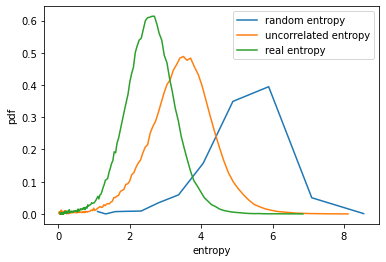

[ True  True  True ...  True  True  True]


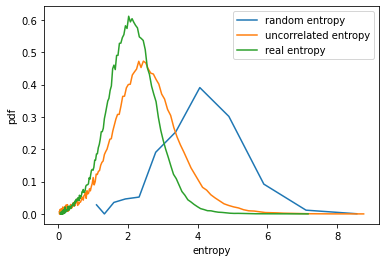

[ True  True  True ...  True  True  True]


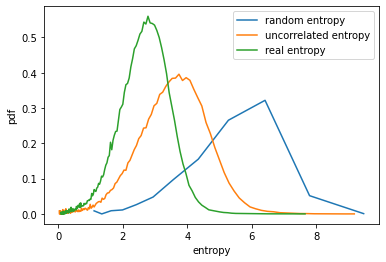

random entropy


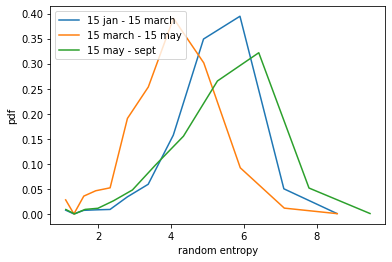

uncorrelated entropy


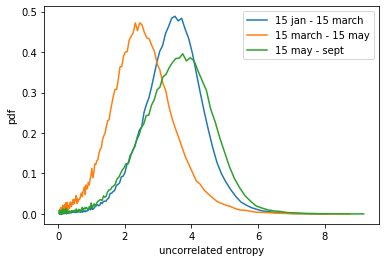

real entropy


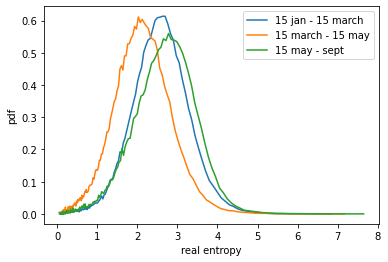

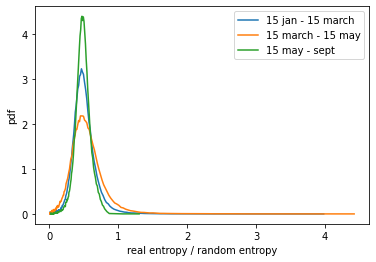

True

In [42]:
from rg_histograms import *
import json
import warnings
import time
warnings.filterwarnings('ignore')


save_dir = '/home/aamaduzzi'
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
# partition by number of points in trajectory
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)
period_division = [half_jan,half_march,half_may,september]
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
legend_entropy = ['random entropy','uncorrelated entropy','real entropy']
print_compression = True
already_plot_type0 = False
print_month_division = True





def plot_entropies_comparison(period_names,legend_entropy,already_plot_type0,print_compression,print_month_division):
    '''Plots random entropy, uncorrelated entropy and real entropy:
    Input:
    ----------------------------
    period_names: list -> ['15 jan - 15 march','15 march - 15 may','15 may - sept']
    legend_entropy: list -> ['random_entropy','uncorrelated_entropy','real_entropy']
    list_: list -> list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
    '''
    ### OPEN UNCORRELATED ENTROPY ###
    dict_period_entropy = dict.fromkeys(period_names)
    dict_period_compression = dict.fromkeys(period_names)    
    dict_type_entropy = dict.fromkeys(legend_entropy)
    dict_stored_entropies = dict.fromkeys(legend_entropy)
    with open('milestones_analysis/uncorrelated_entropy_dictionary/dict_uncorrelated_entropy_bimonth_{}_no_people.json'.format(period_names[2]),'r') as f:
        uncorr_entropy = json.load(f)
    with open('milestones_analysis/random_entropy_dictionary/dict_random_entropy_bimonth_{}_no_people.json'.format(period_names[2]),'r') as f:
        random_entropy = json.load(f)
    entropy_ = pd.DataFrame()        
    for per_ in list(dict_period_entropy.keys()):
        dict_period_entropy[per_] = dict.fromkeys(legend_entropy)
    for per_ in list(dict_period_entropy.keys()):
        dict_period_compression[per_] = []
    
    list_real_entropy = []
    list_random_entropy = []
    list_uncorrelated_entropy = []
    list_compression_entropy = []
    for month in period_names:
        list_random_entropy.extend(list(random_entropy[month]['20']))
        list_uncorrelated_entropy.extend(list(uncorr_entropy[month]['20']))
        for subs in list_:
            entropy_ = pd.read_csv('milestones_analysis/real_entropy_csv_division_time_included/real_entropy_{0}_{1}_{2}.csv'.format(subs,month,'20'),';')
            list_real_entropy.extend(entropy_['real_entropy'])
        list_compression_entropy.extend(np.array(list_real_entropy,dtype = float)/np.array(list(random_entropy[month]['20'][:len(list_real_entropy)]), dtype = float))
        print(np.isfinite(np.array(list_compression_entropy)))
        list_compression_entropy = [list_compression_entropy[x] for x in range(len(list_compression_entropy)) if np.isfinite(np.array(list_compression_entropy))[x] == True]
        dict_period_compression[month] = list_compression_entropy 
        if not already_plot_type0:
            g,g1,dg = logHist(list_random_entropy,12)
            h,h1,dh = logHist(list_uncorrelated_entropy,200)
            q,a,dq=logHist(list_real_entropy,200)
            plt.plot(g1,g)
            plt.plot(h1,h)
            plt.plot(a,q)
            plt.xlabel('{}'.format('entropy'))
            plt.ylabel('pdf')
#            plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
            plt.legend(legend_entropy)
            if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
                os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
            plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'all_entropies_{}'.format(month)))
            plt.show()
        dict_period_entropy[month]['random entropy'] = list_random_entropy
        dict_period_entropy[month]['uncorrelated entropy'] = list_uncorrelated_entropy
        dict_period_entropy[month]['real entropy'] = list_real_entropy
        list_real_entropy = []
        list_random_entropy = []
        list_uncorrelated_entropy = []
        list_compression_entropy = []
    # PLOTTING PER MONTH
    # ENTROPY
    if print_month_division:
        for ty_ in legend_entropy:
            print(ty_)
            if ty_ == 'random entropy':
                g,g1,dg = logHist(dict_period_entropy[period_names[0]][ty_],12)
                h,h1,dh = logHist(dict_period_entropy[period_names[1]][ty_],12)
                q,a,dq=logHist(dict_period_entropy[period_names[2]][ty_],12)
            else:
                g,g1,dg = logHist(dict_period_entropy[period_names[0]][ty_],200)
                h,h1,dh = logHist(dict_period_entropy[period_names[1]][ty_],200)
                q,a,dq=logHist(dict_period_entropy[period_names[2]][ty_],200)
            plt.plot(g1,g)
            plt.plot(h1,h)
            plt.plot(a,q)
            plt.xlabel('{}'.format(ty_))
            plt.ylabel('pdf')
#            plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
            plt.legend(period_names)
            if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
                os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
            plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'{}_comparison_months'.format(ty_)))
            plt.show()
        # COMPRESSION
    if print_compression:
        for month in period_names:
            h,h1,dh = logHist(dict_period_compression[month],200)
            plt.plot(h1,h)
            plt.xlabel('{}'.format('real entropy / random entropy'))
            plt.ylabel('pdf')
#            plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
            plt.legend(period_names)
        if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
            os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
        plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'compression_rate_{}'.format(month)))
        plt.show()        

    return True
    
plot_entropies_comparison(period_names,legend_entropy,already_plot_type0,print_compression,print_month_division)


In [41]:
for ty_ in legend_entropy:
    print(ty_)
    if ty_ == 'random entropy':
        g,g1,dg = logHist(dict_period_entropy[period_names[0]][ty_],12)
        h,h1,dh = logHist(dict_period_entropy[period_names[1]][ty_],12)
        q,a,dq=logHist(dict_period_entropy[period_names[2]][ty_],12)
    else:
        g,g1,dg = logHist(dict_period_entropy[period_names[0]][ty_],200)
        h,h1,dh = logHist(dict_period_entropy[period_names[1]][ty_],200)
        q,a,dq=logHist(dict_period_entropy[period_names[2]][ty_],200)
    plt.plot(g1,g)
    plt.plot(h1,h)
    plt.plot(a,q)
    plt.xlabel('{}'.format(ty_))
    plt.ylabel('pdf')
#            plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
    plt.legend(period_names)
    if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
        os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'{}_comparison_months'.format(ty_)))
    plt.show()


random entropy


NameError: name 'dict_period_entropy' is not defined

average compression in  15 jan - 15 march is 0.5121830998556648
standard deviation in compression in  15 jan - 15 march is 0.18074269262091816
average compression in  15 march - 15 may is 0.5544535305636642
standard deviation in compression in  15 march - 15 may is 0.25205599665364814
average compression in  15 may - sept is 0.4919819926293395
standard deviation in compression in  15 may - sept is 0.10730069603530205


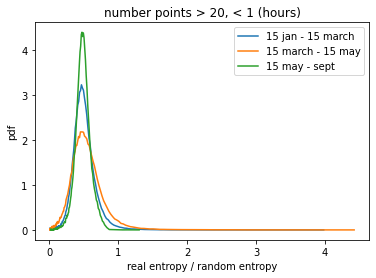

In [105]:
save_dir = '/home/aamaduzzi'
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
# partition by number of points in trajectory
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)
period_division = [half_jan,half_march,half_may,september]
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
legend_entropy = ['random entropy','uncorrelated entropy','real entropy']
with open('milestones_analysis/all_entropies_per_period_plots/dictionary_compression.json','r') as f:
    dict_period_compression = json.load(f)

for month in period_names:
    print('average compression in ',month, 'is {}'.format(np.array(dict_period_compression[month]).mean()))
    print('standard deviation in compression in ',month, 'is {}'.format(np.std(np.array(dict_period_compression[month]))))
g,g1,dg = logHist(dict_period_compression[period_names[0]],200)
f,f1,df = logHist(dict_period_compression[period_names[1]],200)
h,h1,dh = logHist(dict_period_compression[period_names[2]],200)
plt.plot(g1,g)
plt.plot(f1,f)
plt.plot(h1,h)
plt.xlabel('{}'.format('real entropy / random entropy'))
plt.ylabel('pdf')
plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
plt.legend(period_names)
plt.show()        


In [57]:
list_real_entropy = []
list_random_entropy = []
list_uncorrelated_entropy = []
for month in period_names:
    for subs in list_:
        entropy_ = pd.read_csv('milestones_analysis/real_entropy_csv_division_time_included/real_entropy_{0}_{1}_{2}.csv'.format(subs,month,'20'),';')
        list_real_entropy.extend(entropy_['real_entropy'])
        list_random_entropy.extend(list(random_entropy[month]['20']))
        list_uncorrelated_entropy.extend(list(uncorr_entropy[month]['20']))
    g,g1,dg = logHist(list_random_entropy,12)
    h,h1,dh = logHist(list_uncorrelated_entropy,200)
    q,a,dq=logHist(list_real_entropy,200)
    plt.plot(g1,g)
    plt.plot(h1,h)
    plt.plot(a,q)
    plt.xlabel('{}'.format('entropy'))
    plt.ylabel('pdf')
    plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
    plt.legend(legend_entropy)
    if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
        os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'all_entropies_{}'.format(month)))
    plt.show()
    list_real_entropy = []
    list_random_entropy = []
    list_uncorrelated_entropy = []

array([ True,  True,  True, ...,  True,  True,  True])

# PLOTTING CONTRACTION FOR USER ID IN DIFFERENT PERIODS

number of people per plot 182407 	month  15 jan - 15 march
average compression for 15 jan - 15 march 0.6941651297353073
standard deviation compression for 15 jan - 15 march 4.440892098500626e-16
number of people per plot 182407 	month  15 march - 15 may
average compression for 15 march - 15 may 0.7184706016344431
standard deviation compression for 15 march - 15 may 3.3306690738754696e-16
number of people per plot 182407 	month  15 may - sept
average compression for 15 may - sept 0.7499078526695443
standard deviation compression for 15 may - sept 0.0


UnboundLocalError: local variable 'ax' referenced before assignment

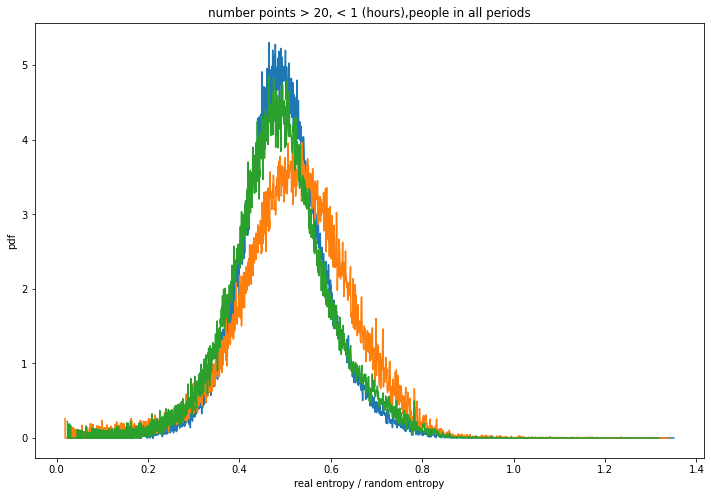

In [210]:
from rg_histograms import *
import json
import warnings
import time
warnings.filterwarnings('ignore')


save_dir = '/home/aamaduzzi'
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
# partition by number of points in trajectory
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)
period_division = [half_jan,half_march,half_may,september]
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
legend_entropy = ['random entropy','uncorrelated entropy','real entropy']
print_compression = True
already_plot_type0 = False
print_month_division = False
def plot_entropies_comparison(period_names,legend_entropy,already_plot_type0,print_compression,print_month_division):
    '''Plots random entropy, uncorrelated entropy and real entropy:
    Input:
    ----------------------------
    period_names: list -> ['15 jan - 15 march','15 march - 15 may','15 may - sept']
    legend_entropy: list -> ['random_entropy','uncorrelated_entropy','real_entropy']
    list_: list -> list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
    '''
    ### OPEN UNCORRELATED ENTROPY ###
    dict_period_entropy = dict.fromkeys(period_names)
    dict_period_compression = {}
    dict_compression_total = {}
    for month in period_names:
        dict_period_compression[month] = []
    for month in period_names:
        dict_compression_total[month] = []

    with open('milestones_analysis/random_entropy_dictionary/dict_random_entropy_bimonth__threshold_1_hour_weighted_by_time.json','r') as f:
        random_entropy = json.load(f)  
    for per_ in list(dict_period_entropy.keys()):
        dict_period_entropy[per_] = dict.fromkeys(legend_entropy)
        for en in legend_entropy:
            d = {'userId':[],'value':[]}
            dict_period_entropy[per_][en] = d    
    list_compression_entropy = []
    list_name_rand_e = []
    list_name_real_e = []
    list_users = []
    for month in period_names:
        for subs in list_:
            entropy_ = pd.read_csv('milestones_analysis/real_entropy_csv_division_time_included/real_entropy_{0}_{1}_{2}_users_included.csv'.format(subs,month,'20'),';')
            dict_period_entropy[month]['real entropy']['userId'].extend(entropy_['userId'])
            dict_period_entropy[month]['real entropy']['value'].extend(entropy_['real_entropy'])
    people_all_periods = 0
    any_people = 0
    for user in random_entropy[period_names[0]]['20']['userId']:
        for month in period_names:
            if user in random_entropy[period_names[1]]['20']['userId'] and user in random_entropy[period_names[2]]['20']['userId']:  
                if random_entropy[month]['20']['value'][random_entropy[month]['20']['userId'] == user]!= 0:
                    dict_period_compression[month].append(dict_period_entropy[month]['real entropy']['value'][dict_period_entropy[month]['real entropy']['userId'] == user]/random_entropy[month]['20']['value'][random_entropy[month]['20']['userId'] == user])
                    people_all_periods = people_all_periods + 1 
                    list_users.append(user)
            dict_compression_total[month].append(dict_period_entropy[month]['real entropy']['value'][dict_period_entropy[month]['real entropy']['userId'] == user]/random_entropy[month]['20']['value'][random_entropy[month]['20']['userId'] == user])
            any_people = any_people + 1
    for user in random_entropy[period_names[1]]['20']['userId']:
        if user not in list_users:
            dict_compression_total[month].append(dict_period_entropy[month]['real entropy']['value'][dict_period_entropy[month]['real entropy']['userId'] == user]/random_entropy[month]['20']['value'][random_entropy[month]['20']['userId'] == user])
            any_people = any_people + 1
            list_users.append(user)
    for user in random_entropy[period_names[2]]['20']['userId']:
        if user not in list_users:
            dict_compression_total[month].append(dict_period_entropy[month]['real entropy']['value'][dict_period_entropy[month]['real entropy']['userId'] == user]/random_entropy[month]['20']['value'][random_entropy[month]['20']['userId'] == user])
            any_people = any_people + 1     
            list_users.append(user)
#### RIGHT PLOTTING PROCEDURE #######   
    fig = plt.figure(figsize = (12,8))
    ax = plt.subplot(111)
    for month in period_names:
        print('number of people per plot',len(dict_period_compression[month]),'\tmonth ',month)
        print('average compression for {}'.format(month),np.array(dict_period_compression[month]).mean())
        print('standard deviation compression for {}'.format(month),np.std(np.array(dict_period_compression[month])))        
        dict_period_compression[month] = [dict_period_entropy[month]['real entropy']['value'][k]/random_entropy[month]['20']['value'][k] for k in range(len(dict_period_entropy[month]['real entropy']['value'])) if random_entropy[month]['20']['value'][k]!=0]
        h,h1,dh = logHist(dict_period_compression[month],3000)
        plt.plot(h1,h)
        plt.xlabel('{}'.format('real entropy / random entropy'))
        plt.ylabel('pdf')
        plt.title('number points > {0}, < {1} (hours),people in all periods'.format('20','1'))
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])    
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.legend(period_names)
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'compression_rate_{}_people_in_all_periods'.format(month)),dpi = 350)
    plt.show()
    print('number of people that appear in all 3 periods', people_all_periods)
    print('number of people that appear in the first periods', any_people)    
    print(people_all_periods-any_people)
    print('start plotting')
###########################################
    fig = plt.figure()
    ax = plt.subplot(111)
    for month in period_names:

        h,h1,dh = logHist(dict_period_compression[month],3000)
        plt.plot(h1,h)
        plt.xlabel('{}'.format('real entropy / random entropy'))
        plt.ylabel('pdf')
        plt.xlim((0.675,0.775))
        plt.title('number points > {0}, < {1} (hours),people in all periods'.format('20','1'))
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.legend(period_names)
    if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
        os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'compression_rate_{}_people_in_all_periods'.format(month)))
    plt.show()        
    fig = plt.figure()
    ax = plt.subplot(111)
    for month in period_names:
        print('average compression for {}'.format(month),np.array(dict_compression_total[month]).mean())
        print('standard deviation compression for {}'.format(month),np.std(np.array(dict_compression_total[month])))
        h,h1,dh = logHist(dict_compression_total[month],3000)
        plt.plot(h1,h)
        plt.xlabel('{}'.format('real entropy / random entropy'))
        plt.ylabel('pdf')
        plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
        plt.xlim((0.675,0.775))
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.legend(period_names)
    
    if not os.path.exists(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'))):
        os.mkdir(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies')))
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'compression_rate_{}'.format(month)))
    plt.show()        

    return True
    
plot_entropies_comparison(period_names,legend_entropy,already_plot_type0,print_compression,print_month_division)


mean max 0.49620141760977493 mean min 0.4955769512844922 month 15 jan - 15 march
Fail to Reject NUll Hypothesis
0.5
number of people per plot 182328 	month  15 jan - 15 march
average compression for 15 jan - 15 march 0.4959904492566389
standard deviation compression for 15 jan - 15 march 0.09482446289812242
mean max 0.523516517569146 mean min 0.5226255827669327 month 15 march - 15 may
Fail to Reject NUll Hypothesis
0.5
number of people per plot 146690 	month  15 march - 15 may
average compression for 15 march - 15 may 0.5232155260819118
standard deviation compression for 15 march - 15 may 0.1213475079466417
mean max 0.49225182711152987 mean min 0.49145376671118385 month 15 may - sept
Fail to Reject NUll Hypothesis
0.5
number of people per plot 142943 	month  15 may - sept
average compression for 15 may - sept 0.49198221211141296
standard deviation compression for 15 may - sept 0.10730053605768683


<Figure size 432x288 with 0 Axes>

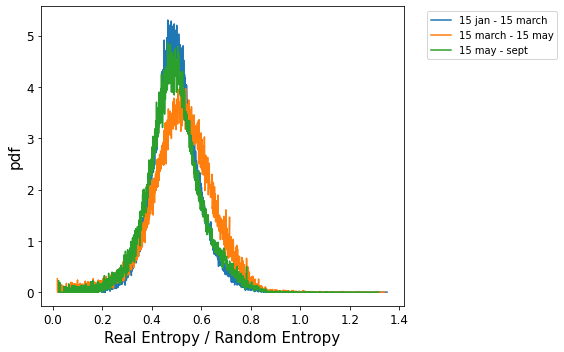

number of people that appear in all 3 periods 471961
2.2522542767883663e-24
Reject Null Hypothesis 15 jan - 15 march/15 march - 15 may
2.103688131940625e-130
Reject Null Hypothesis 15 jan - 15 march/15 may - sept
0.0
Reject Null Hypothesis 15 march - 15 may/15 jan - 15 march
0.0
Reject Null Hypothesis 15 march - 15 may/15 may - sept
6.719211426260398e-32
Reject Null Hypothesis 15 may - sept/15 jan - 15 march
0.08030550102690816
Fail to Reject NUll Hypothesis 15 may - sept/15 march - 15 may
0.08030550102690816


True

In [118]:
from rg_histograms import *
import json
import warnings
import time
from statsmodels.stats.weightstats import ztest as ztest
from scipy import stats
from scipy.stats import ks_2samp
warnings.filterwarnings('ignore')


save_dir = '/home/aamaduzzi'
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
# partition by number of points in trajectory
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)
period_division = [half_jan,half_march,half_may,september]
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
legend_entropy = ['random entropy','uncorrelated entropy','real entropy']
print_compression = True
already_plot_type0 = False
print_month_division = False
def plot_entropies_comparison(period_names,legend_entropy,already_plot_type0,print_compression,print_month_division):
    '''Plots random entropy, uncorrelated entropy and real entropy:
    Input:
    ----------------------------
    period_names: list -> ['15 jan - 15 march','15 march - 15 may','15 may - sept']
    legend_entropy: list -> ['random_entropy','uncorrelated_entropy','real_entropy']
    list_: list -> list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']
    '''
    ### OPEN UNCORRELATED ENTROPY ###
    dict_period_entropy = dict.fromkeys(period_names)
    dict_period_compression = {}
    dict_compression_total = {}
    for month in period_names:
        dict_period_compression[month] = []
    for month in period_names:
        dict_compression_total[month] = []

    with open('milestones_analysis/random_entropy_dictionary/dict_random_entropy_bimonth__threshold_1_hour_weighted_by_time.json','r') as f:
        random_entropy = json.load(f)  
    for per_ in list(dict_period_entropy.keys()):
        dict_period_entropy[per_] = dict.fromkeys(legend_entropy)
        for en in legend_entropy:
            d = {'userId':[],'value':[]}
            dict_period_entropy[per_][en] = d    
    list_compression_entropy = []
    list_name_rand_e = []
    list_name_real_e = []
    list_users = []
    for month in period_names:
        for subs in list_:
            entropy_ = pd.read_csv('milestones_analysis/real_entropy_csv_division_time_included/real_entropy_{0}_{1}_{2}_users_included.csv'.format(subs,month,'20'),';')
            dict_period_entropy[month]['real entropy']['userId'].extend(entropy_['userId'])
            dict_period_entropy[month]['real entropy']['value'].extend(entropy_['real_entropy'])
#### RIGHT PLOTTING PROCEDURE #######   
    fig = plt.figure()
    fig,ax = plt.subplots(1,1,figsize = (8,5))
    people_all_periods = 0
    p = [0,0,0]
    c = 0
    for month in period_names:
        dict_period_compression[month] = [dict_period_entropy[month]['real entropy']['value'][k]/random_entropy[month]['20']['value'][k] for k in range(len(dict_period_entropy[month]['real entropy']['value'])) if random_entropy[month]['20']['value'][k]!=0]
        alpha = 0.05
        ztest_Score, p_value= ztest(dict_period_compression[month],value = np.array(dict_period_compression[month]).mean(), alternative='larger')
        stdv = np.std(dict_period_compression[month])
        avg = np.array(dict_period_compression[month]).mean()
        print('mean max',avg + stdv*0.95/np.sqrt(len(dict_period_compression[month])),'mean min',avg - stdv*0.95*1.96/np.sqrt(len(dict_period_compression[month])),'month',month,)
        if(p_value <  alpha):
            print("Reject Null Hypothesis")     
        else:
            print("Fail to Reject NUll Hypothesis")
            print(p_value)
        # PLOT COMPRESSION RATE
#        y_data = stats.norm.pdf(dict_period_compression[month], avg, stdv)        
#        plt.plot(h1,y_data)
        h,h1,dh = logHist(np.array(dict_period_compression[month]),3000)
        p[c], = plt.plot(h1,h,label = period_names[c])
#        plt.plot(h1, stats.norm.pdf(h1, avg, stdv))
        ax.xaxis.set_tick_params(labelsize=12)
        ax.yaxis.set_tick_params(labelsize=12)
        plt.xlabel('{}'.format('Real Entropy / Random Entropy'),fontsize = 15)
        plt.ylabel('pdf',fontsize = 15)
#        plt.tight_layout()
#        plt.title('number points > {0}, < {1} (hours),people in all periods'.format('20','1'))
        print('number of people per plot',len(dict_period_compression[month]),'\tmonth ',month)
        print('average compression for {}'.format(month),np.array(dict_period_compression[month]).mean())
        print('standard deviation compression for {}'.format(month),np.std(np.array(dict_period_compression[month])))   
        people_all_periods = people_all_periods + len(dict_period_compression[month])
        c = c + 1
#    box = ax.get_position()
#    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])    
#    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    legend_ = ['15 jan - 15 march','15 jan - 15 march','15 march - 15 may','15 march - 15 may','15 may - sept','15 may - sept']
    plt.legend(handles=[p[0],p[1], p[2]],bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join('milestones_analysis','{}_per_period_plots'.format('all_entropies'),'compression_rate_{}_people_in_all_periods'.format(month)),dpi = 400, bbox_inches='tight')
    plt.show()

    print('number of people that appear in all 3 periods', people_all_periods)
###########################################
    Ztest_score = [0,0,0,0,0,0]
    p_value = [0,0,0,0,0,0]
    i = 0
    for period1 in range(len(period_names)):
        for period2 in range(len(period_names)):
            if period1!=period2:
#                print('period1\t',np.shape(np.array(dict_period_compression[period_names[period1]])),'\tperiod2\t',np.shape(np.array(dict_period_compression[period_names[period2]])))
#                Ztest_score[i], p_value[i] = ks_2samp(data1 = np.array(dict_period_compression[period_names[period1]])/np.array(dict_period_compression[period_names[period1]]).mean(),data2 = np.array(dict_period_compression[period_names[period2]])/np.array(dict_period_compression[period_names[period2]]).mean(),alternative = 'less')#,value = np.array(dict_period_compression[period_names[period1]]).mean()- np.array(dict_period_compression[period_names[period2]]).mean())
                Ztest_score[i], p_value[i] = ks_2samp(data1 = np.array(dict_period_compression[period_names[period1]]),data2 = np.array(dict_period_compression[period_names[period2]]),alternative = 'less')#,value = np.array(dict_period_compression[period_names[period1]]).mean()- np.array(dict_period_compression[period_names[period2]]).mean())

                print(p_value[i])
                if(p_value[i] <  alpha):
                    print("Reject Null Hypothesis {0}/{1}".format(period_names[period1],period_names[period2]))     
                else:
                    print("Fail to Reject NUll Hypothesis {0}/{1}".format(period_names[period1],period_names[period2]))
                    print(p_value[i])
                i = 1 + 1
    return True
    
plot_entropies_comparison(period_names,legend_entropy,already_plot_type0,print_compression,print_month_division)


# PRODUCTION REAL ENTROPY WITH USERID

In [116]:
from shapely.geometry import Polygon, LineString, Point
import skmob
from skmob.measures.individual import waiting_times
from datetime import datetime
import math    
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.insert(1,'/data/rgallotti/libraries/PythonScripts/')
from rg_histograms import cumulative,histInt,histFloat,logHist
from rg_fits import power_fit
import geohash
import os
from shapely import *
from geohash_grid import * 
import geopandas as gpd
import warnings
import json
import time
warnings.filterwarnings('ignore')

def calculate_vectorial_quantities(period_names,list_,path,period_division,quantity_to_calculate,t_threshold,t_threshold_true,bounding_box):
    
    for period in range(len(period_names)):
        number_people_per_period = [0,0,0]
        number_points_per_period = [0,0,0]
    #FILLING DICTIONARIES WITH RG and (X/SIGMAX,Y/SIGMAY)            
        for name in list_:
            df = pd.read_parquet(os.path.join(path,name))
            df=df.loc[df['begin']>period_division[period]]
            df=df.loc[df['begin']<period_division[period+1]]        
            print('file {0} in period {1} has length'.format(name,period_names[period]),len(df))
            subs=name.split('.')[0]
            if t_threshold_true:
                df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true)
                print('length of the time thresholded dataframe at {0}: \t {1}'.format(t_threshold,len(df)))
                t_threshold_name =str(t_threshold)
            else:
                t_threshold_name = ''
            for np_ in list_points:
                if quantity_to_calculate == 'gonzalez':
                    list_xsigmax=[]
                    list_ysigmay=[]
                    list_sx=[]
                    list_sy=[]
                    if no_scaled:
                        dataframe_month_point=pd.DataFrame(columns=['x','y'])
                    else:
                        dataframe_month_point=pd.DataFrame(columns=['x_sigmax','y_sigmay'])
                    dataframe_sigma=pd.DataFrame(columns=['sigma_x','sigma_y'])
                else:
                    list_entropy = []
                    list_users = []
                    dataframe_month_point=pd.DataFrame(columns=['real_entropy','userId'])
                # select people with more then np_ points in the trajectory
                infos_dict=df.groupby('userId')
                size_series=infos_dict.size().sort_values()
                list_uid=size_series[size_series>np_].index
                for person in list_uid:
                    number_people_per_period[period] = number_people_per_period[period] + 1
                    if quantity_to_calculate == 'gonzalez':
                        if no_scaled:
                            dataframe_person=pd.DataFrame(columns=['x','y'])
                        else:
                            dataframe_person=pd.DataFrame(columns=['x_sigmax','y_sigmay'])
                    else:
                        dataframe_person=pd.DataFrame(columns=['real_entropy','userId'])
# constructing radius_gyration
                    df_person_month_np = infos_dict.get_group(person)
                    std1=skmob.TrajDataFrame(df_person_month_np, latitude='clusterLatitude', longitude='clusterLongitude', datetime='begin', user_id='userId')
                    std1 = spatial_filtering_per_country(std1,bounding_box)
                    number_points_per_period[period] = number_points_per_period[period] + len(std1)
                    if quantity_to_calculate == 'gonzalez':
                        l_sigmal, sigmas = Gonzalez(df_person_month_np,no_scaled)
                        list_xsigmax.extend(np.array(l_sigmal).T[0].tolist())
                        list_ysigmay.extend(np.array(l_sigmal).T[1].tolist())
                        list_sx.append(np.array(sigmas)[0])
                        list_sy.append(np.array(sigmas)[1])
                    else:
                        real_entropy = skmob.measures.individual.real_entropy(std1,show_progress=False)
                        list_entropy.extend(real_entropy['real_entropy'])
                        list_users.extend(real_entropy['uid'])
                    del std1
                if quantity_to_calculate == 'gonzalez':
                    if no_scaled:
                        dataframe_month_point['x']=list_xsigmax
                        dataframe_month_point['y']=list_ysigmay
                    else:
                        dataframe_month_point['x_sigmax']=list_xsigmax
                        dataframe_month_point['y_sigmay']=list_ysigmay                
                    dataframe_sigma['sigma_x']=list_sx
                    dataframe_sigma['sigma_y']=list_sy
                else:
                    dataframe_month_point['real_entropy'] = list_entropy
                    dataframe_month_point['userId'] = list_users                    
                if quantity_to_calculate == 'gonzalez':
                    if no_scaled:
                        dataframe_month_point.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}_no_scaled.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")
                        print('I have saved:','milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}_no_scaled.csv'.format(subs,period_names[period],np_))
                    else:
                        dataframe_month_point.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")
                        print('I have saved:','milestones_analysis/gonzalez_csv_division_time_included/gonzalez_{0}_{1}_{2}.csv'.format(subs,period_names[period],np_))
                    dataframe_sigma.to_csv('milestones_analysis/gonzalez_csv_division_time_included/gonzalez_sigma_{0}_{1}_{2}.csv.gz'.format(subs,period_names[period],np_),';',compression="gzip")            
                else:
                    if not os.path.exists('milestones_analysis/real_entropy_csv_division_time_included'):
                        os.mkdir('milestones_analysis/real_entropy_csv_division_time_included')
                    dir_ = 'milestones_analysis/real_entropy_csv_division_time_included'
                    name_file = 'real_entropy_{0}_{1}_{2}_users_included.csv.gz'.format(subs,period_names[period],np_)
                    dataframe_month_point.to_csv(os.path.join(dir_,name_file),';',compression="gzip")
                    print('I have saved:',os.path.join(dir_,name_file))
        print('number of people during the period {0} '.format(period_names[period]),number_people_per_period[period])
        print('number of points during the period {0} '.format(period_names[period]),number_points_per_period[period])
    return True


calculate_vectorial_quantities(period_names,list_,path,period_division,quantity_to_calculate,t_threshold,t_threshold_true,bounding_box)
quantity_to_calculate = 'real_entropy'
t_threshold = 1
t_threshold_true = True
filter_q_true = False
bounding_box = [(18.91619,-171.791110603 ), (71.3577635769,-171.791110603), (71.3577635769, -66.96466),(18.91619,-66.96466 ) ]
list_=['subset_1.snappy.parquet','subset_2.snappy.parquet','subset_3.snappy.parquet','subset_4.snappy.parquet','subset_5.snappy.parquet','subset_6.snappy.parquet','subset_7.snappy.parquet','subset_8.snappy.parquet','subset_9.snappy.parquet','subset_a.snappy.parquet','subset_b.snappy.parquet','subset_c.snappy.parquet','subset_d.snappy.parquet','subset_e.snappy.parquet','subset_f.snappy.parquet']

calculate_vectorial_quantities(period_names,list_,path,period_division,quantity_to_calculate,t_threshold,t_threshold_true,bounding_box)

file subset_1.snappy.parquet in period 15 jan - 15 march has length 2003775
length of the time thresholded dataframe at 1: 	 2003439
length of the time thresholded dataframe at 1: 	 2003439
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_1_15 jan - 15 march_20_users_included.csv
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_1_15 jan - 15 march_50_users_included.csv
file subset_2.snappy.parquet in period 15 jan - 15 march has length 2660890
length of the time thresholded dataframe at 1: 	 2660484
length of the time thresholded dataframe at 1: 	 2660484
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_2_15 jan - 15 march_20_users_included.csv
I have saved: milestones_analysis/real_entropy_csv_division_time_included/real_entropy_subset_2_15 jan - 15 march_50_users_included.csv
file subset_3.snappy.parquet in period 15 jan - 15 march has length 2651507


True

# P(N)

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


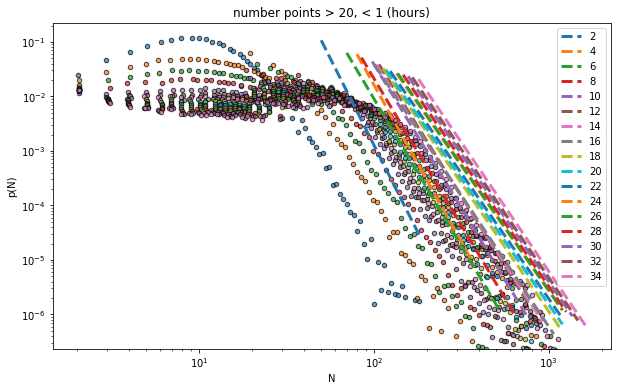

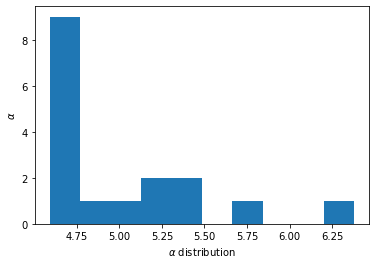

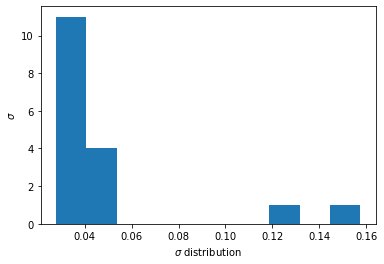

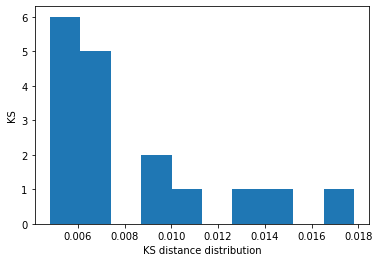

In [348]:
import powerlaw
fig,ax = plt.subplots(1,1,figsize = (10,6))
list_alpha = []
list_sigma = []
list_KS = []
list_xmin = []
for week_interval in list_week:
    list_per_plot = [x for x in dict_M_from_periods[week_interval] if x>1]
    h,h1,dh = logHist(list_per_plot,100)
    plt.scatter(h1,h,s=20, alpha=0.7, edgecolors="k")
    fit = powerlaw.Fit(list_per_plot)
#    print('KS distance \t', fit.power_law.D)        
    alpha = fit.power_law.alpha
    sigma =  fit.power_law.sigma
    list_alpha.append(alpha)
    list_sigma.append(sigma)
    list_KS.append(fit.power_law.D)
    list_xmin.append(fit.xmin)
#    print('sigma \t {}'.format(sigma),'\t alpha \t {}'.format(alpha))
#    print('xmin\t',fit.xmin,'xmax\t',fit.xmax)
    R,p = fit.distribution_compare('power_law', 'exponential')
    fit.power_law.plot_pdf( linestyle='--',linewidth = 3,ax = ax)
    plt.legend([r'$\alpha$ = {}'.format(alpha),'15 march - 15 may'])
    
    plt.xlabel('{}'.format('N'))
    plt.ylabel('p(N)')
    plt.legend(list_week)
    plt.title('number points > {0}, < {1} (hours)'.format('20','1'))
plt.show()

# ALPHA
plt.hist(list_alpha)
plt.xlabel(r'$\alpha$ distribution')
plt.ylabel(r'$\alpha$')
plt.show()

# SIGMA
plt.hist(list_sigma)
plt.xlabel(r'$\sigma$ distribution')
plt.ylabel(r'$\sigma$')
plt.show()

# KS
plt.hist(list_KS)
plt.xlabel('KS distance distribution')
plt.ylabel('KS')
plt.show()


# S(t)

In [126]:
## NOTA: l'algoritmo necessita tanto tempo, è successo di doverlo utilizzare in diverse tranches. Per tale motivo i periodi sono trattati separatamente a discapito dell'automizzazione
## si è preferito tenere il codice separato per una fase di debugging. TODO: rendere tutto una semplice funzione i cui parametri in entrata siano pochi. 
import skmob
from skmob.measures.individual import waiting_times
from datetime import datetime
import math    
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.insert(1,'/data/rgallotti/libraries/PythonScripts/')
from rg_histograms import cumulative,histInt,histFloat,logHist
from rg_fits import power_fit
import geohash
import os
from shapely import *
from geohash_grid import * 
import geopandas as gpd
import warnings
import json
import time
warnings.filterwarnings('ignore')

## INPUT FILES CONFIG ##
path = '/data/shared/cuebiq/MOBS/20220330_stops_hq_users_MA'
#list_files=['subset_1.snappy.parquet','subset_2.snappy.parquet','subset_3.snappy.parquet','subset_4.snappy.parquet','subset_5.snappy.parquet','subset_6.snappy.parquet','subset_7.snappy.parquet','subset_8.snappy.parquet','subset_9.snappy.parquet','subset_a.snappy.parquet','subset_b.snappy.parquet','subset_c.snappy.parquet','subset_d.snappy.parquet','subset_e.snappy.parquet','subset_f.snappy.parquet']
list_files = ['subset_d.snappy.parquet','subset_e.snappy.parquet','subset_f.snappy.parquet'] # 'subset_b.snappy.parquet','subset_c.snappy.parquet',
list_files_path = [os.path.join(path,file) for file in list_files]

## SAVING OPTIONS ##
save_dir = '/home/aamaduzzi'
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']

## DATETIME CONFIG ##
time_format = '%Y-%m-%d %H:%M:%S'
list_week = list(np.arange(2,10,2,dtype = int))  
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)
period_division = [half_jan,half_march,half_may,september]
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
list_month = period_names

# CHOICE ABOUT TRAJECTORIES PARAMETERS
list_points = [20]
t_threshold_name = '1'
list_t_threshold = [1]
t_threshold_true = True
t_threshold = 1
np_ = 20

def n_new_visits(data):
    visits_error = False
    list_visited = []
    list_count_new = []
    count_new = 0
    for x in data:
        if x not in list_visited:
            count_new = count_new + 1
            list_count_new.append(count_new)
            list_visited.append(x)
        else:
            list_count_new.append(count_new)
#            list_visited.append(x)
    for t in range(len(list_count_new)-1):
        if list_count_new[t]>list_count_new[t+1]:
            print('something with counting new visits is wrong')
            visits_error = True
            break
    
    return list_count_new,visits_error
def get_time_passing(df):
    '''Adds a column time_diff that contains the difference in times between two successive
    rows of dataframe 
    '''
    time_error = False
    list_time_diff =[0]
    df=df.sort_values(by = 'begin')
    # list of hours passed from the beginning, length of the list = number of stop points
    list_time_diff.extend(((df.begin.to_numpy(dtype = 'datetime64[s]')-df.begin.to_numpy(dtype = 'datetime64[s]')[0])/3600).astype(int).tolist())
    list_time_diff.pop()
    for t in range(len(list_time_diff)-1):
        if list_time_diff[t]>list_time_diff[t+1]:
            print('something with time ordering is wrong')
            print(list_time_diff)
            time_error = True
            break
    return list_time_diff,time_error

def S_t(list_files_path,period_division,period_names,time_interval_s,dist_s):
    '''Input:
    list_files_path: list of files to be read. [/home/aamad/subset_1.snappy.parquet,...,...]
    period_division: list of datetime [datetime(1,1,2022),...,] -> partition in time
    period_names: list_of names of periods ['jan-march',...,] -> names partition
    time_interval_s: np.linspace(0,h_interval,h_spacing)
    dict_s = {period_names[0]('jan-march'):{0: , 1: , ... ,h_interval: },.., period_names[n]}
    ---------------------------------
    Description:
    A) for each period in period_division: -> prd
        **********
        number_iteration before changing = |file| * |people|
        **********
        -- prd = fixed --
        -- file = changing --
        --  person = changing changing --
        -- stop-time = changing changing chenging --
        B) for each file in the directory:->file
            **********
            number_iteration before changing =  |people|
            **********
            -- prd = fixed --
            -- file = fixed --
            -- person = changing --
            -- stop-time = changing changing --
            1) Open file
            2) Filter trajectories: 
                2a) Stop points closer then one hour
                2b) Number of points bigger then np_ 
                2c) Period
            
            C) for person in list_people:
                1) create a list of successive stop-times intervals -> i.e. t_jan = [0,5,100,..,h_max]
                2) create a list of successive unique-visits 1<->1 with above -> i.e. s_jan = [0,0,1,2,2,...,s_max]
                
                D) for e in list of stop-times:
                1) initialize h as the stop_time t_jan[e]
                2) check not at the end
                3) go until t_jan[e+1] adding dict_s[prd][h] wiht the count if e is not the last element
                4) once u achieve the last element of the list, fill the missing data with the last element. (elif e==len(t_jan)-1)
                
                
                    
    ---------------------------------
    Output:
    dict_s:
    dict_s.keys() in period_names ['jan-march',...]
    dict_s.values() = dict_s_values, dict_s_values.keys() in time_interval_s [0,...,h_interval]
    dict_s_values.values() = [S_0t,...,S_npeoplet] -> count of different positions visited by all the people at their intrinsic time-frame.
    
    '''
    for prd in range(len(period_division)):
        for file in list_files_path:
            # START FIRST COMMON FILTER
            df = pd.read_parquet(file)
            df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true)    
            # END FIRST COMMON FILTER
        #### JAN 
            df_jan=df.loc[df['begin']>period_division[prd]].copy()
            df_jan=df_jan.loc[df_jan['begin']<period_division[prd + 1]]
            list_uid = filter_people_by_np(df_jan,np_)
            infos_dict = df_jan.groupby('userId')
            for person in list_uid:
                dfg = infos_dict.get_group(person)
                t_jan,time_error = get_time_passing(dfg)
                s_jan,visits_error = n_new_visits(dfg['geohash7'])
                if time_error == True or visits_error == True:
                    print('something wrong has happened with',person,'break and pass to next person')
                    break
                if len(s_jan)!= len(t_jan):
                    print('s and t dont have same n of elements for',person,'in january')
                    break
                t0 = time.time()
                # for each stop location of the user at steak 
                for e in range(len(t_jan)):
                    h = t_jan[e]
                    # dividing the time in periods [t_jan[e],t_jan[e]+1,...,t_jan[e+1]]
                    if e<len(t_jan)-1 and t_jan[e+1]-t_jan[e]>0 : # if I have not arrived at the end (as I will call the successive element of the iterator at e), and if the time is increasin
                        for i in range(t_jan[e+1]-t_jan[e]): # as many times as the hours between two successive events
                            if e<len(t_jan)-1: # redundantly ensuring that e is not the last element and I can take the iterator e+1
                                if h==t_jan[e] or (t_jan[e]<h and h<t_jan[e+1]): # take just those cases for which the hour is in 
                                    if h<max(time_interval_s):
                                        dict_s[period_names[prd]][h].append(s_jan[e])
                                        h = h +1
                                elif h<t_jan[e]:
                                    pass
                                else:
                                    break
                            elif e==len(t_jan)-1:
                                while h<max(time_interval_s):
                                    dict_s[period_names[prd]][h].append(s_jan[e])
                                    h = h+1
                t1 = time.time()
        return dict_s


### END FUNCTIONS AND VARIABLES OF NEED ####
##### S(t) #######

from datetime import datetime,timedelta
s_jan = []
t_jan = []
s_march = []
t_march = []
s_may = []
t_may = []
time_interval_s = np.linspace(0,2100,2101)
legend_plot = [r' $k^{-1.22 \pm 0.02}$',r' $k^{-1.25 \pm 0.02}$',r' $k^{-1.10 \pm 0.01}$','15 jan - 15 march','15 march - 15 may','15 may - sept']

#dict_s = dict.fromkeys(period_names)
#for period in period_names:
#    dict_s[period] = dict.fromkeys(time_interval_s)
#    for h in dict_s[period].keys():
#        dict_s[period][h] = []

for file in list_files_path:
    # START FIRST COMMON FILTER
    df = pd.read_parquet(file)
    df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true)    
    # END FIRST COMMON FILTER
#### JAN 
    df_jan=df.loc[df['begin']>period_division[0]].copy()
    df_jan=df_jan.loc[df_jan['begin']<period_division[1]]
    list_uid = filter_people_by_np(df_jan,np_)
    infos_dict = df_jan.groupby('userId')
    for person in list_uid:
        dfg = infos_dict.get_group(person)
        t_jan,time_error = get_time_passing(dfg)
        s_jan,visits_error = n_new_visits(dfg['geohash7'])
        if time_error == True or visits_error == True:
            print('something wrong has happened with',person,'break and pass to next person')
            break
        if len(s_jan)!= len(t_jan):
            print('s and t dont have same n of elements for',person,'in january')
            break
        t0 = time.time()
        # for each stop location of the user at steak 
        for e in range(len(t_jan)):
            h = t_jan[e]
            # dividing the time in periods [t_jan[e],t_jan[e]+1,...,t_jan[e+1]]
            if e<len(t_jan)-1 and t_jan[e+1]-t_jan[e]>0 : # if I have not arrived at the end (as I will call the successive element of the iterator at e), and if the time is increasin
                for i in range(t_jan[e+1]-t_jan[e]): # as many times as the hours between two successive events
                    if e<len(t_jan)-1: # redundantly ensuring that e is not the last element and I can take the iterator e+1
                        if h==t_jan[e] or (t_jan[e]<h and h<t_jan[e+1]): # take just those cases for which the hour is in 
                            if h<max(time_interval_s):
                                dict_s[period_names[0]][h].append(s_jan[e])
                                h = h +1
#                                print('hour\t',h,'append\t',s_jan[e],'e\t',e,'iteration\t',i,'dict_s[{0}][{1}]'.format(period_names[0],h),'len\t',len(dict_s[period_names[0]][h-1]),dict_s[period_names[0]][h])
    #                        for k in range(len(dict_s[period_names[0]][i])-1):
    #                            if i>0 and dict_s[period_names[0]][i-1][k]>dict_s[period_names[0]][i][k]:
    #                                print('I have an error of',dict_s[period_names[0]][i-1][k]-dict_s[period_names[0]][i][k],'for person',person)
                        elif h<t_jan[e]:
                            pass
                        else:
                            break
                    elif e==len(t_jan)-1 and h>t_jan[e] or h==t_jan[e]:
                        dict_s[period_names[0]][h].append(s_jan[e])
#                print('iteration\t',i)
        t1 = time.time()
#        print(person,'hour\t',h,'append\t',s_jan[e],'e\t',e,'dict_s[{0}][{1}]'.format(period_names[0],h),'len\t',len(dict_s[period_names[0]][h-1]),dict_s[period_names[0]][h-1])
#        for h in dict_s[period_names[0]].keys():
#            print(h,'\t',dict_s[period_names[0]][h])
#        print('time_person',t1-t0)
#### MARCH     
    df_march=df.loc[df['begin']>period_division[1]]
    df_march=df_march.loc[df_march['begin']<period_division[2]]
    list_uid = filter_people_by_np(df_march,np_)
    infos_dict = df_march.groupby('userId')
    for person in list_uid:
        dfg = infos_dict.get_group(person)
        t_march,time_error = get_time_passing(dfg)
        s_march,visits_error = n_new_visits(dfg['geohash7'])
        if time_error == True or visits_error == True:
            print('something wrong has happened with',person,'break and pass to next person')
            break

        if len(s_march)!= len(t_march):
            print('s and t dont have same n of elements for',person,'in march')
            break        
        for e in range(len(t_march)):
            h = t_march[e]
            if e<len(t_march)-1 and t_march[e+1]-t_march[e]>0 :
                for i in range(t_march[e+1]-t_march[e]):
                    if e<len(t_march)-1:
                        if h==t_march[e] or t_march[e]<h<t_march[e+1]:
                            if h<max(time_interval_s):
                                dict_s[period_names[1]][h].append(s_march[e])
                                h = h +1                        
                        elif h<t_march[e]:
                            pass                    
                        else:
                            break
                    elif e==len(t_march)-1 and h>t_march[e] or h==t_march[e]:
                        dict_s[period_names[1]][h].append(s_march[e])
#### MAY
    df_may=df.loc[df['begin']>period_division[2]]
    df_may=df_may.loc[df_may['begin']<period_division[3]] 
    list_uid = filter_people_by_np(df_may,np_)
    infos_dict = df_may.groupby('userId')
    for person in list_uid:
        dfg = infos_dict.get_group(person)
        t_may,time_error = get_time_passing(dfg)
        s_may,visits_error = n_new_visits(dfg['geohash7'])
        if time_error == True or visits_error == True:
            print('something wrong has happened with',person,'break and pass to next person')
            break

        if len(s_may)!= len(t_may):
            print('s and t dont have same n of elements for',person,'in may')
            break

        for e in range(len(t_may)):
            h = t_may[e]
            if e<len(t_may)-1 and t_may[e+1]-t_may[e]>0 :
                for i in range(t_may[e+1]-t_may[e]):
                    if e<len(t_may)-1:
                        if h==t_may[e] or t_may[e]<h<t_may[e+1]:
                            if h < max(time_interval_s):
                                dict_s[period_names[2]][h].append(s_may[e])
                                h = h + 1
                        elif h<t_may[e]:
                            pass                    
                        else:
                            break
                    elif e==len(t_may)-1 and h>t_may[e] or h==t_may[e]:
                        dict_s[period_names[2]][h].append(s_may[e])
with open("milestones_analysis/dict_s_t.json","w") as f:
    json.dump(dict_s,f)

        
list_mean_per_s = []
for period in period_names:
    for time in dict_s[period].keys():
        list_mean_per_s.append(np.array(dict_s[period][time]).mean())
    mask = np.isfinite(list_mean_per_s)
    masknan = np.isnan(np.array(list_mean_per_s)[mask])
    slope,std_err, r_value, intercept = power_fit(np.array(list_mean_per_s)[mask],time_interval_s)
    u_spacing =0.18 *np.array(time_interval_s)**slope
    ax.scatter(time_interval_s, list_mean_per_s, s=60, alpha=0.7, edgecolors="k")
    ax.loglog(list_mean_per_s, u_spacing, linestyle = 'dashed')
    plt.xlabel('t')
    plt.ylabel('S(t)')
    ax.set_xscale("log")
    ax.set_yscale('log')
    print('\naverage slope per period:\t',period_names[period],slope,'std deviation slope is:\t',std_err)
plt.legend(legend_plot)
#plt.title('S(t) for different periods')
#plt.savefig('milestones_analysis/location_frequency/plot_three_periods',dpi = 350)

plt.show()



length of the time thresholded dataframe at 1: 	 7499697
number of points 20
number of people which have more than 20 points: 12425
number of points 20
number of people which have more than 20 points: 10014
number of points 20
number of people which have more than 20 points: 9749
length of the time thresholded dataframe at 1: 	 7537131
number of points 20
number of people which have more than 20 points: 12318
number of points 20
number of people which have more than 20 points: 9940
number of points 20
number of people which have more than 20 points: 9689
length of the time thresholded dataframe at 1: 	 7543690
number of points 20
number of people which have more than 20 points: 12425
number of points 20
number of people which have more than 20 points: 9965
number of points 20
number of people which have more than 20 points: 9764


ValueError: operands could not be broadcast together with shapes (1439,) (2101,) 


average slope per period:	 15 jan - 15 march -1.2171166842682726 std deviation slope is:	 0.024577154159726052

average slope per period:	 15 march - 15 may -1.2476338710581636 std deviation slope is:	 0.015470395561284024

average slope per period:	 15 may - sept -1.1010137017839743 std deviation slope is:	 0.010747182392320736


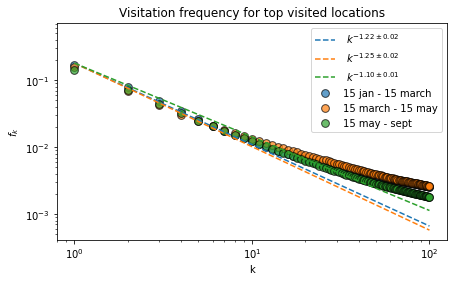

In [341]:
#legend_plot = ['15 jan - 15 march','15 march - 15 may','15 may - sept','15 jan - 15 march','15 march - 15 may','15 may - sept']
legend_plot = [r' $k^{-1.22 \pm 0.02}$',r' $k^{-1.25 \pm 0.02}$',r' $k^{-1.10 \pm 0.01}$','15 jan - 15 march','15 march - 15 may','15 may - sept']

fig, ax = plt.subplots(figsize = (7, 4))
for period in range(len(period_names)):  
    list_mean_per_k = []
    for k in dict_frequency_degree[period_names[period]].keys():
        list_mean_per_k.append(np.array(dict_frequency_degree[period_names[period]][k]).mean())
    mask = np.isfinite(list_mean_per_k)
    masknan = np.isnan(np.array(list_mean_per_k)[mask])
    slope,std_err, r_value, intercept = power_fit(np.array(list_mean_per_k)[mask],spacing)
#    list_slopes.append(slope)
    
#    q,a,dh = logHist(list_slopes,100)
    u_spacing =0.18 *np.array(spacing)**slope
    ax.scatter(spacing, list_mean_per_k, s=60, alpha=0.7, edgecolors="k")
    ax.loglog(spacing, u_spacing, linestyle = 'dashed')
    # Set logarithmic scale on the x variable
#    plt.loglog(spacing,list_mean_per_k)
    plt.xlabel('k')
    plt.ylabel(r'$f_k$')
    ax.set_xscale("log")
    ax.set_yscale('log')
    print('\naverage slope per period:\t',period_names[period],slope,'std deviation slope is:\t',std_err)
plt.legend(legend_plot)
plt.title('Visitation frequency for top visited locations')
plt.savefig('milestones_analysis/location_frequency/plot_three_periods',dpi = 350)

plt.show()


(181786,)


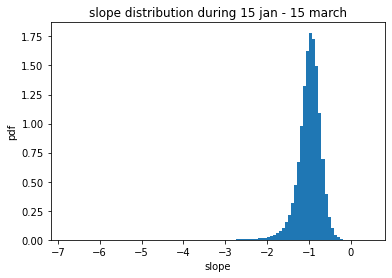


average slope per period:	 15 jan - 15 march -0.9940083574093811 std deviation slope is:	 0.27911604757779923


In [280]:
print(np.shape(list_slopes))
#q,a,dh = 
#plt.scatter(q,a)
mask = np.isfinite(list_slopes)
list_slopes = np.array(list_slopes)[mask]
plt.hist(list_slopes,100,density = True)
plt.xlabel('slope')
plt.ylabel('pdf')
plt.title('slope distribution during {}'.format(period_names[period]))
plt.show()

print('\naverage slope per period:\t',period_names[period],np.array(list_slopes).mean(),'std deviation slope is:\t',np.std(list_slopes))


# FREQUENCY LOCATION WITH DIFFERENT THRESHOLD

In [432]:
def stop_time(x,y):
    return ((x.to_numpy(dtype = 'datetime64[s]') - y.to_numpy(dtype = 'datetime64[s]'))/3600).astype(int)
def filter_by_length_stop(df,t_filter_h):
#    df=df.sort_values(by = 'begin')
    df['tot_stay_h'] = df.apply(lambda row: stop_time(row['end'],row['begin']))#((df.end.to_numpy(dtype = 'datetime64[s]')-df.begin.to_numpy(dtype = 'datetime64[s]'))/3600).astype(int).tolist()
    df = df.loc[df['tot_stay_h']>t_filter_h]
    return df
## INPUT FILES CONFIG ##
path = '/data/shared/cuebiq/MOBS/20220330_stops_hq_users_MA'
list_files=['subset_1.snappy.parquet','subset_2.snappy.parquet','subset_3.snappy.parquet','subset_4.snappy.parquet','subset_5.snappy.parquet','subset_6.snappy.parquet','subset_7.snappy.parquet','subset_8.snappy.parquet','subset_9.snappy.parquet','subset_a.snappy.parquet','subset_b.snappy.parquet','subset_c.snappy.parquet','subset_d.snappy.parquet','subset_e.snappy.parquet','subset_f.snappy.parquet']
list_files_path = [os.path.join(path,file) for file in list_files]

## SAVING OPTIONS ##
save_dir = '/home/aamaduzzi'
list_=['subset_1','subset_2','subset_3','subset_4','subset_5','subset_6','subset_7','subset_8','subset_9','subset_a','subset_b','subset_c','subset_d','subset_e','subset_f']

## DATETIME CONFIG ##
time_format = '%Y-%m-%d %H:%M:%S'
list_week = list(np.arange(2,36,2,dtype = int))  
half_jan = datetime(2020,1,15)
half_march = datetime(2020,3,15)
half_may = datetime(2020,5,15)
september = datetime(2020,9,30)
period_division = [half_jan,half_march,half_may,september]
period_names = ['15 jan - 15 march','15 march - 15 may','15 may - sept']
list_month = period_names

###GEOMETRICAL
bounding_box = [(18.91619,-171.791110603 ), (71.3577635769,-171.791110603), (71.3577635769, -66.96466),(18.91619,-66.96466 ) ]

# CHOICE ABOUT TRAJECTORIES PARAMETERS
list_points = [20]
t_threshold_name = '1'
list_t_threshold = [1]
t_threshold_true = True
t_threshold = 1
np_ = 20
spacing = np.linspace(0,100,101,dtype = int)
dict_frequency_degree = dict.fromkeys(period_names)

filter_stays = [1,2,8,24]
for tf in filter_stays:
    for period in range(len(period_names)):
        list_slopes = []
        list_mean_per_k = []
        dict_frequency_degree[period_names[period]] = dict.fromkeys(spacing)
        for k in dict_frequency_degree[period_names[period]].keys():
            dict_frequency_degree[period_names[period]][k] = [] 
        for file in list_files_path:
            # OPEN
            df = pd.read_parquet(file)
            # FILTER BY PERIOD
            df = filter_by_period(df,period_division,period)
            # FILTER BY TIME
            df = time_filtering_traj_per_person(df,t_threshold,t_threshold_true)
            df = filter_by_length_stop(df,tf)
            # FILTER BY PEOPLE
            list_uid = filter_people_by_np(df,np_)
            infos_dict = df.groupby('userId')
            for person in list_uid:
                df_person_month_np = infos_dict.get_group(person)
                std1=skmob.TrajDataFrame(df_person_month_np, latitude='clusterLatitude', longitude='clusterLongitude', datetime='begin', user_id='userId')
                std1 = spatial_filtering_per_country(std1,bounding_box)
                quantity=skmob.measures.individual.location_frequency(std1,show_progress = False)
                for k in dict_frequency_degree[period_names[period]].keys():
                    if k<len(quantity):
                        dict_frequency_degree[period_names[period]][k].append(quantity.loc[k]['datetime'])
    for period in range(len(period_names)):  
        list_mean_per_k = []
        for k in dict_frequency_degree[period_names[period]].keys():
            list_mean_per_k.append(np.array(dict_frequency_degree[period_names[period]][k]).mean())
        slope,std_err, r_value, intercept = power_fit(list_mean_per_k,spacing)
    #    list_slopes.append(slope)

    #    q,a,dh = logHist(list_slopes,100)
        plt.scatter(spacing,list_mean_per_k)
        plt.xlabel('Rank')
        plt.ylabel('pdf')
        plt.title(' {}'.format(period_names[period]))
        plt.savefig('fk_filter_{}'.format(tf))
        plt.show()

        print('\naverage slope per period:\t',period_names[period],np.array(list_slopes).mean(),'std deviation slope is:\t',np.std(list_slopes))
#    if True:
#        break




length of the time thresholded dataframe at 1: 	 2003439


IndexError: index 9 is out of bounds for axis 0 with size 8

82196252    2020-01-15 00:06:42
55361046    2020-01-15 00:07:01
62571526    2020-01-15 00:07:06
38903036    2020-01-15 00:08:25
107959412   2020-01-15 00:08:36
                    ...        
70825857    2020-05-31 22:56:55
54335969    2020-06-04 00:15:23
58483522    2020-06-14 22:53:54
39917333    2020-06-14 22:59:02
76998672    2020-06-21 22:54:12
Name: end, Length: 2003439, dtype: datetime64[ns]

# PRODUCTION RANDOM ENTROPY WITH USERID